<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%207/W07_L2_Backpropagation_in_RNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=vZQP26PHNOk) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%207/NPTEL_Jul24_DL4CV_W07_P02.pdf)

In [1]:
# Week 7, Lecture 2: Backprop in RNN's
from IPython.display import HTML, display

VIDEO_ID = "vZQP26PHNOk"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 7, Lecture 2: Backpropagation in RNNs

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§7.2 Backprop in RNNs**.

This notebook takes the recurrence from the previous lecture and differentiates it by hand: every gradient
the slides derive is implemented from scratch on plain tensors and checked against autograd, and then the
two failure modes of that gradient, vanishing and exploding, are measured on a task where the network has
to remember something for $T$ steps.

**What you will learn**
- **Backpropagation through time (BPTT)**: because the same $W$ is used at every step, the gradient is a sum over steps, $\partial E/\partial W = \sum_t \partial E_t/\partial W$.
- The easy gradient $\partial E_3/\partial V = (\hat y_3 - y_3) \otimes h_3$, and why the same one-line shortcut is **wrong** for $W$.
- The full formula $\frac{\partial E_3}{\partial W} = \sum_{k=0}^{3} \frac{\partial E_3}{\partial \hat y_3}\frac{\partial \hat y_3}{\partial h_3}\left(\prod_{j=k+1}^{3}\frac{\partial h_j}{\partial h_{j-1}}\right)\frac{\partial h_k}{\partial W}$, implemented term by term and verified for $U$, $V$, $W$ and both biases.
- Why the **product of Jacobians** $\partial h_t/\partial h_k$ vanishes when $\sigma_{\max}(W) < 1$ and can explode when it is larger, and how the activation (tanh, ReLU, identity) changes the factor.
- **Truncated BPTT** with parameters $(k_1, k_2)$, and how much of the true gradient it throws away.
- **Gradient clipping** (Pascanu et al., ICML 2013), and a measured rescue of training on a long-lag memory task.
- The slide's homework: simpler fixes for vanishing gradients that keep the architecture unchanged.

**Contents**

1. Forward pass and the loss
2. BPTT: the gradient is a sum over time steps
3. The easy gradient: $\partial E_3/\partial V$
4. The gradient for $W$, and why one term is not enough
5. The sum over $k$ and the product of Jacobians
6. Vanishing gradients: the norm of $\partial h_t/\partial h_k$
7. The activation decides the factor: tanh, ReLU, identity
8. Truncated BPTT
9. Exploding gradients and gradient clipping
10. The slide's homework, answered
11. Explore and verify

**How to run**  Everything is tiny and runs in a few minutes on **Colab CPU or GPU** (no GPU
needed). Run the setup cell first, then go top to bottom.


## Review

The previous lecture built the recurrence $h_t = \tanh(Ux_t + Wh_{t-1})$, $\hat y_t = \mathrm{softmax}(Vh_t)$
and showed that the same three matrices are reused at every step, so an RNN's parameter count does not grow
with the sequence length. The review questions on the first slides of this deck push on that: an RNN can have
more than one hidden layer (**stacked RNNs**, several recurrent blocks feeding each other), and the state
$h_t$ records information from all previous steps, morphed a little by each new input. If the state is morphed
too much, the effect of earlier steps is washed out, which is undesirable for sequence learning. This lecture
asks the question that decides whether any of this can be trained: how do we compute the gradient of the loss
with respect to $U$, $V$ and $W$ when $W$ is applied over and over, and what happens to that gradient as
the sequence gets long?


## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import sys, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed

def set_seed(seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
set_seed(0)

# Device: this line works unchanged on CPU and GPU runtimes.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
plt.rcParams['figure.dpi'] = 100

def npy(x):
    '''Tensor (on any device) to a numpy array, for printing and plotting.'''
    return x.detach().cpu().numpy()

print('torch', torch.__version__, '| device:', device)


torch 2.8.0 | device: cpu


## 1. Forward pass and the loss

The slides fix the forward pass and the loss before touching any derivative:

$$h_t = \tanh(U x_t + W h_{t-1}), \qquad \hat y_t = \mathrm{softmax}(V h_t)$$

$$E_t(y_t, \hat y_t) = -y_t \log \hat y_t, \qquad E = \sum_t E_t = -\sum_t y_t \log \hat y_t$$

Here $y_t$ is a one-hot target, so $-y_t\log\hat y_t$ picks out the log-probability of the correct class:
this is the per-step **cross-entropy**, and the total error $E$ is the sum of the per-step errors. (Denny
Britz's WildML tutorial, which the slides credit, writes the state as $s_t$ and the output as $o_t$; we keep
the slides' $h_t$ and $\hat y_t$.) The slides omit biases; `nn.RNN` and `nn.Linear` have them, so we carry a
hidden bias $b$ and an output bias $c$ along and verify their gradients too.

We build a model small enough to check by hand: $D = 3$ input features, $H = 4$ hidden units, $C = 5$
classes, $T = 4$ steps. The forward pass is written with plain tensors and then checked against `nn.RNN`.


In [3]:
D, H, C, T = 3, 4, 5, 4                      # input, hidden, classes, timesteps

def init_params(D, H, C, w_scale=0.5, seed=0):
    '''Random U, W, V, b, c as leaf tensors that autograd can differentiate.
    W is drawn with standard deviation w_scale so the recurrent gain is easy to control.'''
    set_seed(seed)
    P = {'U': torch.randn(H, D, device=device),
         'W': torch.randn(H, H, device=device) * w_scale,
         'V': torch.randn(C, H, device=device),
         'b': torch.randn(H, device=device) * 0.1,
         'c': torch.randn(C, device=device) * 0.1}
    for p in P.values():
        p.requires_grad_(True)
    return P

def rnn_forward(P, xs, h0=None):
    '''The slide's forward pass: h_t = tanh(U x_t + W h_{t-1} + b), z_t = V h_t + c.
    Returns the list of hidden states (h_0 .. h_{T-1}) and the (T, C) logits z_t.'''
    h = torch.zeros(P['W'].shape[0], device=xs.device) if h0 is None else h0
    hs, logits = [], []
    for x in xs:
        h = torch.tanh(P['U'] @ x + P['W'] @ h + P['b'])
        hs.append(h); logits.append(P['V'] @ h + P['c'])
    return hs, torch.stack(logits)

P = init_params(D, H, C)
U, W, V, b, c = (P[k] for k in 'UWVbc')
set_seed(1)
xs = torch.randn(T, D, device=device)
ys = torch.randint(0, C, (T,), device=device)

hs, logits = rnn_forward(P, xs)
print('hidden states :', [tuple(h.shape) for h in hs][:2], '...  logits:', tuple(logits.shape))

# The idiomatic version: nn.RNN carries two bias vectors (input side and hidden side); ours is their sum.
ref = nn.RNN(D, H, nonlinearity='tanh').to(device)
with torch.no_grad():
    ref.weight_ih_l0.copy_(U); ref.weight_hh_l0.copy_(W)
    ref.bias_ih_l0.copy_(b);   ref.bias_hh_l0.zero_()
ref_out = nn.Linear(H, C).to(device)
with torch.no_grad():
    ref_out.weight.copy_(V); ref_out.bias.copy_(c)
h_ref, _ = ref(xs[:, None, :])                     # (T, 1, H)
logits_ref = ref_out(h_ref[:, 0])
assert torch.allclose(torch.stack(hs), h_ref[:, 0], atol=1e-6), 'from-scratch RNN disagrees with nn.RNN'
assert torch.allclose(logits, logits_ref, atol=1e-6)
print(f'from-scratch forward vs nn.RNN + nn.Linear: max |difference| = {(torch.stack(hs) - h_ref[:, 0]).abs().max():.2e}')


hidden states : [(4,), (4,)] ...  logits: (4, 5)
from-scratch forward vs nn.RNN + nn.Linear: max |difference| = 1.19e-07


The loss is the slide's definition, written out: softmax, then $-\log$ of the probability at the true class,
then a sum over steps. `F.cross_entropy` does exactly this, and we check that it does.


In [4]:
def cross_entropy_scratch(z, y):
    '''E_t = -y_t log yhat_t with yhat_t = softmax(z_t) and y_t one-hot, for one step.'''
    log_yhat = z - torch.logsumexp(z, dim=0)     # log softmax, computed stably
    return -log_yhat[y]

per_step = torch.stack([cross_entropy_scratch(logits[t], ys[t]) for t in range(T)])
per_step_ref = torch.stack([F.cross_entropy(logits[t][None], ys[t][None]) for t in range(T)])
assert torch.allclose(per_step, per_step_ref, atol=1e-6), 'cross entropy from the definition disagrees'
E = per_step.sum()

print(f'targets y_t         : {ys.tolist()}')
print(f'per-step losses E_t : {[round(v, 3) for v in per_step.tolist()]}')
print(f'total E = sum_t E_t : {E.item():.4f}')


targets y_t         : [3, 1, 4, 2]
per-step losses E_t : [2.73, 0.653, 3.221, 0.666]
total E = sum_t E_t : 7.2711


## 2. BPTT: the gradient is a sum over time steps

> "Goal: Calculate gradients of error $E$ w.r.t. weights $U$, $V$, $W$. These gradients will be used to learn
> weights using SGD."

The slide's answer is **Backpropagation Through Time**: because $E = \sum_t E_t$ and differentiation is
linear,

$$\frac{\partial E}{\partial W} = \sum_t \frac{\partial E_t}{\partial W}$$

and the same for $U$ and $V$. That sounds trivial, and it is, but it is the reason BPTT is called what it is:
the unrolled network is one deep feedforward network whose layers share weights, and the gradient for the
shared weight is the sum of what every copy of it receives. We confirm that one backward pass through $E$
equals the sum of $T$ backward passes through the individual $E_t$.


In [5]:
grad_total = torch.autograd.grad(E, W, retain_graph=True)[0]

grad_sum = torch.zeros_like(W)
step_norms = []                                  # |dE_t/dW| for each t, to compare with |sum_t dE_t/dW|
for t in range(T):
    hs_t, logits_t = rnn_forward(P, xs)
    E_t = F.cross_entropy(logits_t[t][None], ys[t][None])
    g_t = torch.autograd.grad(E_t, W)[0]
    grad_sum += g_t; step_norms.append(g_t.norm().item())

assert torch.allclose(grad_total, grad_sum, atol=1e-5), 'sum of per-step gradients disagrees'
print(f'dE/dW from one backward pass vs summing {T} per-step passes:')
print(f'  max |difference| = {(grad_total - grad_sum).abs().max():.2e}')
print(f'  sum of |dE_t/dW| = {sum(step_norms):.4f}  >=  |dE/dW| = {grad_total.norm():.4f}   (per step: {[round(v, 3) for v in step_norms]})')
print('  the per-step norms add up to at least |dE/dW| (triangle inequality); they add up to exactly |dE/dW|')
print('  only when every term points the same way, so the terms here partly cancel')


dE/dW from one backward pass vs summing 4 per-step passes:
  max |difference| = 1.49e-07
  sum of |dE_t/dW| = 4.1339  >=  |dE/dW| = 2.4962   (per step: [0.0, 0.61, 2.813, 0.71])
  the per-step norms add up to at least |dE/dW| (triangle inequality); they add up to exactly |dE/dW|
  only when every term points the same way, so the terms here partly cancel


## 3. The easy gradient: $\partial E_3/\partial V$

The slides consider the error at one time step, $E_3$, and start with $V$ because it is easy: $V$ is applied
once, at the output of step 3, and nothing recurrent stands between it and the loss. Writing $z_3 = Vh_3$,

$$\frac{\partial E_3}{\partial V} = \frac{\partial E_3}{\partial \hat y_3}\frac{\partial \hat y_3}{\partial z_3}\frac{\partial z_3}{\partial V} = (\hat y_3 - y_3) \otimes h_3$$

> "where $\otimes$ is outer product."

The first two factors collapse to $\hat y_3 - y_3$ because the derivative of cross-entropy through a softmax
is prediction minus target, and $\partial z_3/\partial V$ contributes $h_3$. The output bias gets the same
first factor with nothing multiplied on: $\partial E_3/\partial c = \hat y_3 - y_3$. We check both against
autograd. (The slides count steps from 0 with $h_{-1} = 0$, so the slides' $E_3$ is `t = 3` in code, the
fourth step of our $T = 4$ sequence.)


In [6]:
t = 3                                        # the slides' E_3: steps are counted from 0
hs, logits = rnn_forward(P, xs)
E_t = F.cross_entropy(logits[t][None], ys[t][None])
auto_V, auto_c = torch.autograd.grad(E_t, [V, c])

yhat = torch.softmax(logits[t], dim=0)
y_onehot = F.one_hot(ys[t], C).float()
closed_V = torch.outer(yhat - y_onehot, hs[t])
closed_c = yhat - y_onehot

assert torch.allclose(auto_V, closed_V, atol=1e-6), 'closed form for dE/dV disagrees with autograd'
assert torch.allclose(auto_c, closed_c, atol=1e-6), 'closed form for dE/dc disagrees with autograd'
print(f'(yhat - y) outer h  vs  autograd dE_3/dV : max |difference| = {(auto_V - closed_V).abs().max():.2e}')
print(f'(yhat - y)          vs  autograd dE_3/dc : max |difference| = {(auto_c - closed_c).abs().max():.2e}')
print(f'yhat_3 = {npy(yhat).round(3)},  y_3 = {npy(y_onehot)}')
print('the output-layer gradient needs nothing from earlier time steps')


(yhat - y) outer h  vs  autograd dE_3/dV : max |difference| = 1.49e-08
(yhat - y)          vs  autograd dE_3/dc : max |difference| = 1.49e-08
yhat_3 = [0.08  0.218 0.514 0.163 0.024],  y_3 = [0. 0. 1. 0. 0.]
the output-layer gradient needs nothing from earlier time steps


## 4. The gradient for $W$, and why one term is not enough

> "How about $\partial E_3/\partial W$? Can we write it as
> $\frac{\partial E_3}{\partial W} = \frac{\partial E_3}{\partial \hat y_3}\frac{\partial \hat y_3}{\partial h_3}\frac{\partial h_3}{\partial W}$?"

> "It's not complete, since $h_3$ depends on $W$. Chain rule needs to be applied again!"

The expression treats $h_2$ as a constant when computing $\partial h_3/\partial W$, but
$h_3 = \tanh(Ux_3 + Wh_2)$ and $h_2$ was itself produced using $W$. (The slide writes $Ux_2$ inside
$h_3$; the input at step 3 is $x_3$, a typo we correct here.) The chain rule has to follow $W$ into $h_2$,
then into $h_1$, and so on back to the start.

Rather than argue, we reproduce the incomplete gradient: detach $h_2$ from the graph so that autograd
genuinely treats it as a constant, and compare with the full gradient.


In [7]:
def rnn_forward_detached(P, xs, upto):
    '''Same forward pass, but the state entering step `upto` is detached from the graph,
    so autograd sees h_{upto-1} as a constant that does not depend on W.'''
    h = torch.zeros(P['W'].shape[0], device=xs.device)
    hs = []
    for i, x in enumerate(xs):
        if i == upto:
            h = h.detach()
        h = torch.tanh(P['U'] @ x + P['W'] @ h + P['b'])
        hs.append(h)
    return hs

t = 3                                        # the slides' E_3 again
hs_full = rnn_forward(P, xs)[0]
E_full = F.cross_entropy((V @ hs_full[t] + c)[None], ys[t][None])
grad_full = torch.autograd.grad(E_full, W)[0]

hs_cut = rnn_forward_detached(P, xs, upto=t)
E_cut = F.cross_entropy((V @ hs_cut[t] + c)[None], ys[t][None])
grad_cut = torch.autograd.grad(E_cut, W)[0]

rel = (grad_full - grad_cut).norm() / grad_full.norm()
assert rel > 0.01, 'the incomplete gradient should differ noticeably'
print(f'full gradient norm            : {grad_full.norm():.5f}')
print(f'one-term (h_2 constant) norm  : {grad_cut.norm():.5f}')
print(f'relative difference           : {100 * rel:.1f}%   -> the missing terms matter')
print(f'cosine between the two        : {F.cosine_similarity(grad_full.flatten(), grad_cut.flatten(), dim=0):.3f}')


full gradient norm            : 0.71028
one-term (h_2 constant) norm  : 0.48302
relative difference           : 68.7%   -> the missing terms matter
cosine between the two        : 0.729


## 5. The sum over $k$ and the product of Jacobians

> "Observe that $h_3$ depends on $W$ directly as well as indirectly via $h_2, h_1, \ldots$ hence:
> $\frac{\partial E_3}{\partial W} = \sum_{k=0}^{3} \frac{\partial E_3}{\partial \hat y_3}\frac{\partial \hat y_3}{\partial h_3}\frac{\partial h_3}{\partial h_k}\frac{\partial h_k}{\partial W}$"

Each term of the sum is one route by which $W$ influences $E_3$: the copy of $W$ used at step $k$ changes
$h_k$ (that is $\partial h_k/\partial W$, with $h_{k-1}$ held fixed), the change propagates forward through
steps $k+1, \ldots, 3$ (that is $\partial h_3/\partial h_k$), and finally reaches the loss through the output
layer. The middle factor is where the recurrence lives. The slides expand it with the chain rule,
$\frac{\partial h_3}{\partial h_1} = \frac{\partial h_3}{\partial h_2}\frac{\partial h_2}{\partial h_1}$, and in
general

$$\frac{\partial E_3}{\partial W} = \sum_{k=0}^{3} \frac{\partial E_3}{\partial \hat y_3}\frac{\partial \hat y_3}{\partial h_3}\left(\prod_{j=k+1}^{3}\frac{\partial h_j}{\partial h_{j-1}}\right)\frac{\partial h_k}{\partial W}$$

### 5.a The one-step Jacobian

The slides never write out $\partial h_j/\partial h_{j-1}$. For our recurrence it has a closed form: with
$a_j = Ux_j + Wh_{j-1} + b$ and $h_j = \tanh(a_j)$, and $\tanh' = 1 - \tanh^2$,

$$\frac{\partial h_j}{\partial h_{j-1}} = \mathrm{diag}\!\left(1 - h_j^2\right) W$$

an $H \times H$ matrix. We verify it against `torch.autograd.functional.jacobian`, and verify that Jacobians
compose the way the slide says.


In [8]:
from torch.autograd.functional import jacobian

def step(h_prev, x):
    '''One recurrence step with the global parameters.'''
    return torch.tanh(U @ x + W @ h_prev + b)

def jac_tanh_step(h_next, W):
    '''Closed-form Jacobian dh_j/dh_{j-1} = diag(1 - h_j^2) W for a tanh recurrence.'''
    return torch.diag(1 - h_next ** 2) @ W

hs = [h.detach() for h in rnn_forward(P, xs)[0]]
J_auto = jacobian(lambda h: step(h, xs[1]), hs[0])
J_closed = jac_tanh_step(hs[1], W)
assert torch.allclose(J_auto, J_closed, atol=1e-5), 'Jacobian closed form is wrong'
print(f'diag(1 - h^2) W  vs  autograd Jacobian : max |difference| = {(J_auto - J_closed).abs().max():.2e}')
print(f'Jacobian shape {tuple(J_closed.shape)}, one row per unit of h_j, one column per unit of h_(j-1)')

# Jacobians compose: dh3/dh1 == (dh3/dh2) (dh2/dh1)
J21 = jacobian(lambda h: step(h, xs[2]), hs[1])
J32 = jacobian(lambda h: step(h, xs[3]), hs[2])
J31 = jacobian(lambda h: step(step(h, xs[2]), xs[3]), hs[1])
assert torch.allclose(J31, J32 @ J21, atol=1e-5), 'Jacobians do not compose'
print(f'dh3/dh1 vs (dh3/dh2)(dh2/dh1)           : max |difference| = {(J31 - J32 @ J21).abs().max():.2e}')


diag(1 - h^2) W  vs  autograd Jacobian : max |difference| = 1.49e-08
Jacobian shape (4, 4), one row per unit of h_j, one column per unit of h_(j-1)
dh3/dh1 vs (dh3/dh2)(dh2/dh1)           : max |difference| = 2.98e-08


### 5.b The slide's formula, implemented term by term

Now the whole sum. `bptt_explicit` computes $\partial E_t/\partial W$ exactly as the slide writes it: for
every $k \le t$ it forms the product of Jacobians $\partial h_t/\partial h_k$ by multiplying the one-step
matrices, pushes the output error $\partial E_t/\partial h_t = V^\top(\hat y_t - y_t)$ back through it to
get $\partial E_t/\partial h_k$, and multiplies by the local derivative $\partial h_k/\partial W$ with
$h_{k-1}$ held fixed. That local derivative is an outer product, $\left((1 - h_k^2) \odot \partial E_t/\partial h_k\right) \otimes h_{k-1}$.

The slide's homework asks for $\partial E_3/\partial U$: "similar to $\partial E_3/\partial W$". It is the same
sum with the last factor replaced by $\partial h_k/\partial U$, whose outer product uses $x_k$ instead of
$h_{k-1}$, and the hidden bias uses a vector of ones. All three come out of the same loop, and all three
are asserted against autograd.


In [9]:
def bptt_explicit(P, xs, ys, t):
    '''dE_t/dW, dE_t/dU, dE_t/db as the slide's sum over k of (Jacobian product) x (local derivative).
    Also returns |term_k| for W, one number per k, to see where the gradient comes from.'''
    Wm, Vm = P['W'].detach(), P['V'].detach()
    hs, logits = rnn_forward({k: v.detach() for k, v in P.items()}, xs)
    yhat = torch.softmax(logits[t], dim=0)
    dE_dh_t = Vm.t() @ (yhat - F.one_hot(ys[t], logits.shape[1]).float())     # dE_t/dh_t, shape (H,)
    gW, gU, gb = torch.zeros_like(Wm), torch.zeros_like(P['U']), torch.zeros_like(P['b'])
    term_norms = []
    for k in range(t, -1, -1):
        J = torch.eye(Wm.shape[0], device=Wm.device)
        for j in range(k + 1, t + 1):                    # dh_t/dh_k = prod_{j=k+1}^{t} dh_j/dh_{j-1}
            J = jac_tanh_step(hs[j], Wm) @ J
        dE_dh_k = J.t() @ dE_dh_t                        # push the error back to step k
        local = (1 - hs[k] ** 2) * dE_dh_k               # through tanh at step k
        h_prev = hs[k - 1] if k > 0 else torch.zeros_like(hs[k])
        term_W = torch.outer(local, h_prev)              # dh_k/dW with h_{k-1} held fixed
        gW += term_W; gU += torch.outer(local, xs[k]); gb += local
        term_norms.append(term_W.norm().item())
    return gW, gU, gb, term_norms[::-1]                  # term_norms ordered k = 0 .. t

t = 3
hs_f, logits_f = rnn_forward(P, xs)
E_t = F.cross_entropy(logits_f[t][None], ys[t][None])
auto_W, auto_U, auto_b = torch.autograd.grad(E_t, [W, U, b])
gW, gU, gb, terms = bptt_explicit(P, xs, ys, t)

for name, a, m in (('W', auto_W, gW), ('U', auto_U, gU), ('b', auto_b, gb)):
    assert torch.allclose(a, m, atol=1e-5), f'explicit BPTT for {name} disagrees with autograd'
    print(f'dE_{t}/d{name}: explicit sum over k vs autograd  max |difference| = {(a - m).abs().max():.2e}   (|grad| = {a.norm():.4f})')
print(f'\n|term_k| for W, k = 0..{t}: {[round(v, 4) for v in terms]}')
print(f'the k = 0 term is exactly zero: the copy of W at step 0 multiplies h_(-1) = 0')
print(f'the k = t term alone (the one-term shortcut of section 4) is {terms[-1] / gW.norm():.0%} of |dE_{t}/dW|')


dE_3/dW: explicit sum over k vs autograd  max |difference| = 5.96e-08   (|grad| = 0.7103)
dE_3/dU: explicit sum over k vs autograd  max |difference| = 5.96e-08   (|grad| = 0.7959)
dE_3/db: explicit sum over k vs autograd  max |difference| = 5.96e-08   (|grad| = 0.6041)

|term_k| for W, k = 0..3: [0.0, 0.2709, 0.4993, 0.483]
the k = 0 term is exactly zero: the copy of W at step 0 multiplies h_(-1) = 0
the k = t term alone (the one-term shortcut of section 4) is 68% of |dE_3/dW|


### 5.c The same sum as one backward sweep

Computing each $\partial h_t/\partial h_k$ from scratch is quadratic in $t$. The standard BPTT algorithm
walks backwards once, carrying the running vector $\delta_k = \partial E/\partial h_k$ and updating it by
one Jacobian per step, $\delta_{k-1} = W^\top\left((1 - h_k^2)\odot\delta_k\right)$, while adding each
step's outer product into the parameter gradients. It handles all $E_t$ at once by adding the output error
$V^\top(\hat y_k - y_k)$ into $\delta_k$ as it passes step $k$. This is what autograd does. We implement it
for all five parameters and check against a single `torch.autograd.grad` call, and against the explicit
version summed over $t$.


In [10]:
def bptt_backward(P, xs, ys, k2=None):
    '''Full BPTT for E = sum_t E_t: one backward sweep carrying delta_k = dE/dh_k.
    If k2 is given, each step's error is propagated back at most k2 steps (used in section 8).
    Returns a dict of gradients for U, W, V, b, c and the list of |delta_k| for inspection.'''
    Pd = {k: v.detach() for k, v in P.items()}
    hs, logits = rnn_forward(Pd, xs)
    Tn, Cn = logits.shape
    g = {k: torch.zeros_like(v) for k, v in Pd.items()}
    delta = torch.zeros_like(hs[0])
    delta_norms = []
    for k in range(Tn - 1, -1, -1):
        yhat = torch.softmax(logits[k], dim=0)
        dz = yhat - F.one_hot(ys[k], Cn).float()          # dE_k/dz_k
        g['V'] += torch.outer(dz, hs[k]); g['c'] += dz
        delta = delta + Pd['V'].t() @ dz                 # add this step's own error to the running dE/dh_k
        local = (1 - hs[k] ** 2) * delta                 # through tanh
        h_prev = hs[k - 1] if k > 0 else torch.zeros_like(hs[k])
        g['W'] += torch.outer(local, h_prev); g['U'] += torch.outer(local, xs[k]); g['b'] += local
        delta = Pd['W'].t() @ local                      # one Jacobian back
        delta_norms.append(delta.norm().item())
    return g, delta_norms[::-1]

hs_f, logits_f = rnn_forward(P, xs)
E_all = sum(F.cross_entropy(logits_f[t][None], ys[t][None]) for t in range(T))
auto = dict(zip('UWVbc', torch.autograd.grad(E_all, [U, W, V, b, c])))
g, _ = bptt_backward(P, xs, ys)
for name in 'UWVbc':
    assert torch.allclose(auto[name], g[name], atol=1e-5), f'BPTT for {name} disagrees with autograd'
    print(f'dE/d{name}: one-sweep BPTT vs autograd  max |difference| = {(auto[name] - g[name]).abs().max():.2e}')

# The one-sweep gradient equals the explicit double sum, added over t.
gW_sum = sum(bptt_explicit(P, xs, ys, t)[0] for t in range(T))
assert torch.allclose(gW_sum, g['W'], atol=1e-5)
print(f'\nsum over t of the explicit sum over k vs one sweep: max |difference| = {(gW_sum - g["W"]).abs().max():.2e}')


dE/dU: one-sweep BPTT vs autograd  max |difference| = 1.19e-07
dE/dW: one-sweep BPTT vs autograd  max |difference| = 5.96e-08
dE/dV: one-sweep BPTT vs autograd  max |difference| = 5.96e-08
dE/db: one-sweep BPTT vs autograd  max |difference| = 1.19e-07
dE/dc: one-sweep BPTT vs autograd  max |difference| = 1.19e-07

sum over t of the explicit sum over k vs one sweep: max |difference| = 5.96e-08


### 5.d Where each term comes from: the unrolled graph

The figure draws the unrolled network for $E_3$ and one path per $k$. Each path starts at the copy of $W$
used at step $k$, runs through $h_k, h_{k+1}, \ldots, h_3$ (each hop is one Jacobian factor) and exits through
$V$ into $E_3$. The label on each path is the norm of that term of the sum, computed by `bptt_explicit` on
our model. The one-term shortcut of section 4 is the $k = 3$ path alone. The $k = 0$ path (dashed) carries
exactly zero for $W$, because the copy of $W$ used at step 0 multiplies the initial state $h_{-1} = 0$; the
same path carries a non-zero term for $U$, whose outer product uses $x_0$.


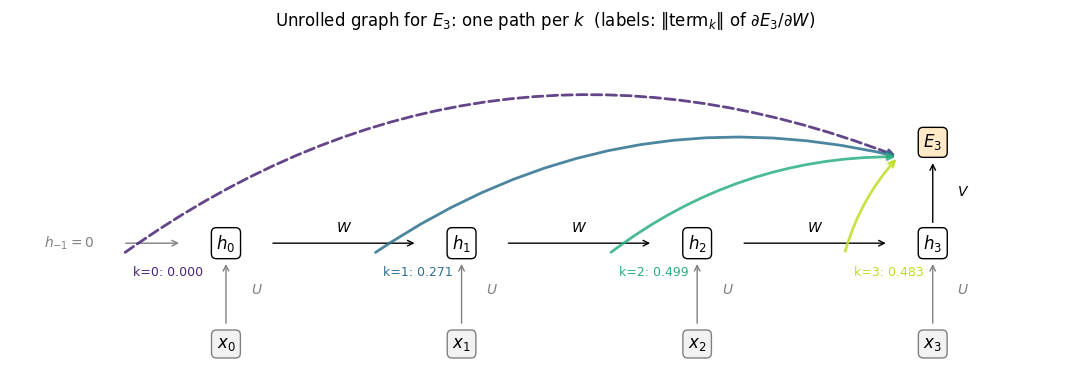

In [11]:
def draw_unrolled(term_norms, t=3, title=r'Unrolled graph for $E_3$: one path per $k$'):
    '''Schematic of the unrolled RNN with the k-th gradient path highlighted per colour.'''
    fig, ax = plt.subplots(figsize=(11, 4))
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, t + 1))
    xpos = np.arange(t + 1) * 2.4
    for k in range(t + 1):
        ax.text(xpos[k], 0, f'$x_{k}$', ha='center', va='center', fontsize=12,
                bbox=dict(boxstyle='round', fc='#f2f2f2', ec='gray'))
        ax.text(xpos[k], 1.4, f'$h_{k}$', ha='center', va='center', fontsize=12,
                bbox=dict(boxstyle='round', fc='white', ec='black'))
        ax.annotate('', xy=(xpos[k], 1.15), xytext=(xpos[k], 0.25), arrowprops=dict(arrowstyle='->', color='gray'))
        ax.text(xpos[k] + 0.25, 0.7, '$U$', color='gray', fontsize=10)
        if k > 0:
            ax.annotate('', xy=(xpos[k] - 0.45, 1.4), xytext=(xpos[k - 1] + 0.45, 1.4),
                        arrowprops=dict(arrowstyle='->', color='black'))
            ax.text((xpos[k] + xpos[k - 1]) / 2, 1.55, '$W$', ha='center', fontsize=10)
    ax.text(xpos[0] - 1.6, 1.4, '$h_{-1}=0$', ha='center', va='center', fontsize=10, color='gray')
    ax.annotate('', xy=(xpos[0] - 0.45, 1.4), xytext=(xpos[0] - 1.05, 1.4), arrowprops=dict(arrowstyle='->', color='gray'))
    ax.text(xpos[t], 2.8, f'$E_{t}$', ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round', fc='#ffe9c6', ec='black'))
    ax.annotate('', xy=(xpos[t], 2.55), xytext=(xpos[t], 1.65), arrowprops=dict(arrowstyle='->', color='black'))
    ax.text(xpos[t] + 0.25, 2.05, '$V$', fontsize=10)
    # one curved path per k, from the W-edge into step k up to the loss
    for k in range(t + 1):
        start = xpos[k] - 0.9 if k > 0 else xpos[0] - 1.05
        ax.annotate('', xy=(xpos[t] - 0.35, 2.6), xytext=(start, 1.25),
                    arrowprops=dict(arrowstyle='->', color=colors[k], lw=2, alpha=0.85,
                                    linestyle='--' if term_norms[k] == 0 else '-',
                                    connectionstyle=f'arc3,rad={-0.12 - 0.05 * (t - k)}'))
        ax.text(start + 0.1, 0.95, f'k={k}: {term_norms[k]:.3f}', color=colors[k], fontsize=9, ha='left')
    ax.set_xlim(xpos[0] - 2.2, xpos[t] + 1.5); ax.set_ylim(-0.5, 4.3); ax.axis('off')
    ax.set_title(title + r'  (labels: $\|\mathrm{term}_k\|$ of $\partial E_3/\partial W$)')
    plt.tight_layout(); plt.show()

draw_unrolled(terms, t=3)


### Widget 1: which $k$ carries the gradient?

The bar chart below shows $\|\mathrm{term}_k\|$ for every $k \ge 1$ in $\partial E_t/\partial W$ on a longer
random model ($H = 8$, $T = 12$; the $k = 0$ term is zero as explained above). The static sweep changes the
scale of $W$: at small scale only the last few $k$ matter, the earlier terms having vanished by orders of
magnitude per step, and at large scale the profile flattens until terms from ten steps back are within a
factor of about twenty of the most recent one (at scale 3.0 and $t = 11$ the smallest term for $k \ge 1$
is about 6% of the largest). Drag `w_scale` and `t` in the widget and watch the profile tilt from
"recent steps only" to "the whole past counts".


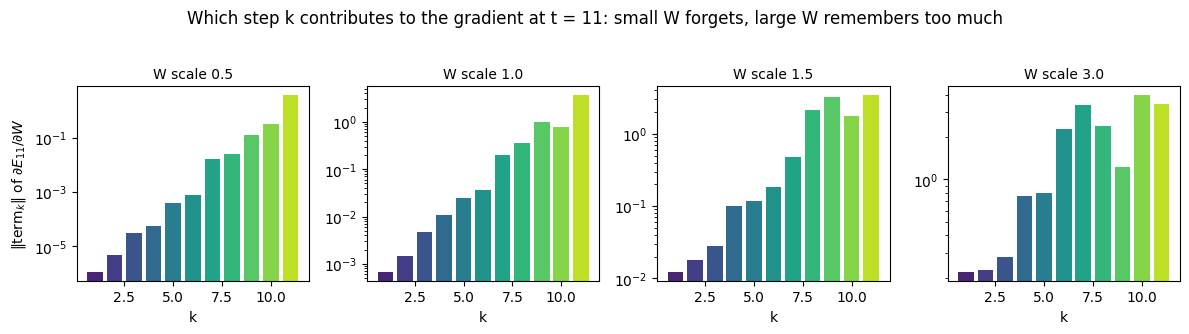

In [12]:
D2, H2, C2, T2 = 3, 8, 4, 12
set_seed(3)
xs2 = torch.randn(T2, D2, device=device)
ys2 = torch.randint(0, C2, (T2,), device=device)

def term_profile(w_scale, t, seed=0):
    '''|term_k| for k = 0..t of dE_t/dW on a random model with recurrent weight scale w_scale.'''
    P2 = init_params(D2, H2, C2, w_scale=w_scale / math.sqrt(H2), seed=seed)
    return bptt_explicit(P2, xs2, ys2, t)[3][1:]          # drop the k = 0 term, which is identically zero

scales = [0.5, 1.0, 1.5, 3.0]
fig, axes = plt.subplots(1, len(scales), figsize=(12, 3.2), sharey=False)
for ax, s in zip(axes, scales):
    prof = term_profile(s, T2 - 1)
    ax.bar(range(1, T2), prof, color=plt.cm.viridis(np.linspace(0.1, 0.9, T2 - 1)))
    ax.set_yscale('log'); ax.set_xlabel('k'); ax.set_title(f'W scale {s}', fontsize=10)
axes[0].set_ylabel(r'$\|\mathrm{term}_k\|$ of $\partial E_{11}/\partial W$')
fig.suptitle('Which step k contributes to the gradient at t = 11: small W forgets, large W remembers too much', y=1.03)
plt.tight_layout(); plt.show()


Now the same thing under your control. Drag the slider and watch what changes.

In [13]:
def term_widget(w_scale=1.0, t=11):
    prof = term_profile(w_scale, t)
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.bar(range(1, t + 1), prof, color=plt.cm.viridis(np.linspace(0.1, 0.9, t)))
    ax.set_yscale('log'); ax.set_xlabel('k (the step whose copy of W the term comes from)')
    ax.set_ylabel(r'$\|\mathrm{term}_k\|$')
    ax.set_title(f'W scale {w_scale:.2f}, t = {t}: earliest / latest term = {prof[0] / prof[-1]:.2e}')
    plt.tight_layout(); plt.show()

interact(term_widget,
         w_scale=FloatSlider(min=0.25, max=4.0, step=0.25, value=1.0, continuous_update=False),
         t=IntSlider(min=1, max=T2 - 1, step=1, value=T2 - 1, continuous_update=False));


interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='w_scale', max=4.0, min=0.25…

## 6. Vanishing gradients: the norm of $\partial h_t/\partial h_k$

> "Sequences (sentences) can be quite long, perhaps 20 words or more - need to backpropagate through many
> layers! $\Rightarrow$ Vanishing Gradient Problem!"

> "For sigmoid activations, gradient is upper bounded by 1; what does this tell us? Gradients will vanish
> over time, and long-range dependencies will not contribute at all!"

The product $\prod_{j=k+1}^{t}\partial h_j/\partial h_{j-1}$ has $t - k$ factors, one per step of lag. Each
factor is $\mathrm{diag}(f'(a_j))\,W$, and $f'$ is bounded: $\tanh' \le 1$, and for the logistic sigmoid
$\sigma' \le 1/4$. Multiply many matrices each shrinking its input and the product goes to zero
exponentially in the lag, so the terms with small $k$ in the sum of section 5 contribute nothing. The slide's
"upper bounded by 1" is exactly right for tanh and loose for the logistic sigmoid, as we check first.


max tanh'(z)    = 1.0000   (attained at z = 0)
max sigmoid'(z) = 0.2500   (attained at z = 0)

losing a factor 1e-6 takes 131 steps at 0.9 per step, and only 10 steps at the sigmoid bound 0.25 per step


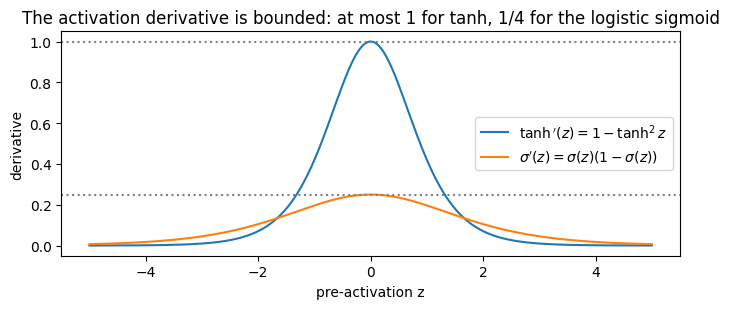

In [14]:
z = torch.linspace(-5, 5, 1001)
tanh_prime = 1 - torch.tanh(z) ** 2
sig = torch.sigmoid(z)
sigmoid_prime = sig * (1 - sig)

print(f"max tanh'(z)    = {tanh_prime.max():.4f}   (attained at z = 0)")
print(f"max sigmoid'(z) = {sigmoid_prime.max():.4f}   (attained at z = 0)")
assert abs(tanh_prime.max() - 1.0) < 1e-6
assert abs(sigmoid_prime.max() - 0.25) < 1e-6
n_tanh = math.log(1e-6) / math.log(0.9)      # illustrative: a factor 0.9 per step (tanh in its mid range)
n_sig = math.log(1e-6) / math.log(0.25)
print(f'\nlosing a factor 1e-6 takes {n_tanh:.0f} steps at 0.9 per step, and only {n_sig:.0f} steps at the sigmoid bound 0.25 per step')

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(npy(z), npy(tanh_prime), label=r"$\tanh'(z) = 1 - \tanh^2 z$")
ax.plot(npy(z), npy(sigmoid_prime), label=r"$\sigma'(z) = \sigma(z)(1-\sigma(z))$")
ax.axhline(1.0, ls=':', color='gray'); ax.axhline(0.25, ls=':', color='gray')
ax.set_xlabel('pre-activation z'); ax.set_ylabel('derivative'); ax.legend()
ax.set_title('The activation derivative is bounded: at most 1 for tanh, 1/4 for the logistic sigmoid')
plt.tight_layout(); plt.show()


### 6.a The spectral criterion

The activation bound is one factor; the other is $W$. Pascanu, Mikolov and Bengio (*On the difficulty of
training recurrent neural networks*, ICML 2013) make the condition precise. With $\gamma$ the bound on
$|f'|$ ($\gamma = 1$ for tanh, $1/4$ for the sigmoid) and $\sigma_{\max}(W)$ the largest singular value of
$W$,

$$\left\|\frac{\partial h_j}{\partial h_{j-1}}\right\| \le \gamma\,\sigma_{\max}(W)
\qquad\Longrightarrow\qquad
\left\|\frac{\partial h_t}{\partial h_k}\right\| \le \left(\gamma\,\sigma_{\max}(W)\right)^{t-k}$$

so $\gamma\,\sigma_{\max}(W) < 1$ is a **sufficient condition for vanishing** gradients, and
$\gamma\,\sigma_{\max}(W) > 1$ is **necessary for exploding** ones (necessary, not sufficient: the
$f'$ factors can be much smaller than $\gamma$ when the units saturate, so a large $W$ does not
guarantee growth). The spectral radius $\rho(W)$, the largest $|$eigenvalue$|$, plays the same role for
the long-run rate when $W$ acts many times.

We measure $\|\partial h_t/\partial h_k\|_2$ directly for a lag of up to 40 steps, with $H = 32$ and
$W$ drawn as $\mathcal N(0, s^2/H)$ so that $\sigma_{\max}(W) \approx 2s$ (for a Gaussian matrix of this
size), and print $\sigma_{\max}$, $\rho$ and the bound alongside.


In [15]:
def jacobian_product_norms(Wm, hs, act='tanh'):
    '''Spectral norm of dh_t/dh_k for t = last step and every k, computed by multiplying one-step Jacobians.
    Returns norms indexed by lag t - k = 0, 1, ..., t.'''
    t = len(hs) - 1
    J = torch.eye(Wm.shape[0], device=Wm.device)
    norms = [1.0]
    for j in range(t, 0, -1):
        if act == 'tanh':
            J = J @ (torch.diag(1 - hs[j] ** 2) @ Wm)
        elif act == 'relu':
            J = J @ (torch.diag((hs[j] > 0).float()) @ Wm)
        else:                                            # identity activation
            J = J @ Wm
        norms.append(torch.linalg.matrix_norm(J, ord=2).item())
    return norms

def run_recurrence(Wm, xs_in, act='tanh'):
    '''Drive the recurrence h_t = f(x_t + W h_{t-1}) with the inputs already projected into R^H.'''
    h = torch.zeros(Wm.shape[0], device=Wm.device); hs = []
    f = {'tanh': torch.tanh, 'relu': torch.relu, 'identity': lambda a: a}[act]
    for x in xs_in:
        h = f(x + Wm @ h); hs.append(h)
    return hs

def make_W(scale, H=32, seed=0):
    '''Gaussian recurrent matrix with entries N(0, scale^2 / H); sigma_max is about 2 * scale.'''
    set_seed(seed)
    return torch.randn(H, H, device=device) * scale / math.sqrt(H)

def spectral_stats(Wm):
    smax = torch.linalg.matrix_norm(Wm, ord=2).item()
    rho = torch.linalg.eigvals(Wm).abs().max().item()
    return smax, rho

H6, T6 = 32, 40
set_seed(0)
xs6 = torch.randn(T6, H6, device=device)             # inputs already projected to H dims

print(f'{"scale s":>8} {"sigma_max":>10} {"rho(W)":>8} {"|dh_t/dh_k| lag 10":>20} {"lag 20":>10} {"lag 40":>10} {"bound at lag 20":>16}')
curves = {}
for s in (0.25, 0.5, 0.9, 1.1, 1.5, 3.0):
    Wm = make_W(s, H6)
    smax, rho = spectral_stats(Wm)
    n = jacobian_product_norms(Wm, run_recurrence(Wm, xs6))
    curves[s] = (n, smax, rho)
    print(f'{s:>8.2f} {smax:>10.3f} {rho:>8.3f} {n[10]:>20.2e} {n[20]:>10.2e} {n[-1]:>10.2e} {smax ** 20:>16.2e}')


 scale s  sigma_max   rho(W)   |dh_t/dh_k| lag 10     lag 20     lag 40  bound at lag 20
    0.25      0.505    0.260             1.03e-07   1.99e-15   3.15e-30         1.17e-06
    0.50      1.010    0.520             7.02e-05   1.07e-09   2.95e-19         1.23e+00
    0.90      1.818    0.937             1.09e-02   1.26e-05   2.38e-10         1.56e+05
    1.10      2.223    1.145             3.86e-02   2.37e-04   7.30e-08         8.65e+06
    1.50      3.031    1.561             6.67e-01   6.35e-02   1.82e-04         4.28e+09
    3.00      6.061    3.123             3.69e+01   1.76e+03   1.24e+05         4.48e+15


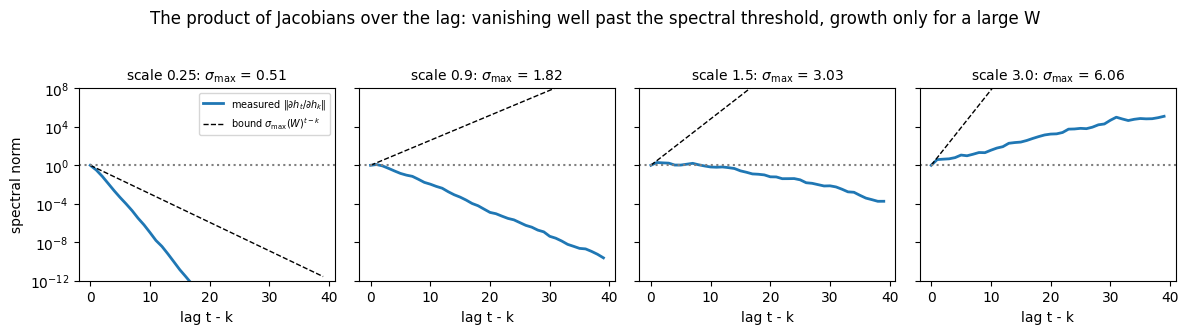

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2), sharey=True)
for ax, s in zip(axes, (0.25, 0.9, 1.5, 3.0)):
    n, smax, rho = curves[s]
    lags = np.arange(len(n))
    ax.semilogy(lags, n, lw=2, label=r'measured $\|\partial h_t/\partial h_k\|$')
    ax.semilogy(lags, smax ** lags, 'k--', lw=1, label=r'bound $\sigma_{\max}(W)^{t-k}$')
    ax.axhline(1, color='gray', ls=':')
    ax.set_title(f'scale {s}: ' + r'$\sigma_{\max}$' + f' = {smax:.2f}', fontsize=10)
    ax.set_xlabel('lag t - k')
axes[0].set_ylabel('spectral norm'); axes[0].legend(fontsize=7)
axes[0].set_ylim(1e-12, 1e8)
fig.suptitle('The product of Jacobians over the lag: vanishing well past the spectral threshold, growth only for a large W', y=1.03)
plt.tight_layout(); plt.show()


Three things are worth reading off the table. First, the sufficient condition works: at scale 0.25
($\sigma_{\max} = 0.5$) the norm at lag 20 is $10^{-15}$, the slide's "long-range dependencies will not
contribute at all", and the decay is even faster than the bound. Second, the bound is loose. The largest
singular value of a Gaussian matrix is about twice its typical one, so $\sigma_{\max}$ overstates what
a random direction experiences; the spectral radius $\rho(W)$ is closer to the real per-step rate, and
the tanh factors $1 - h_j^2$ shrink it further. That is why the product still decays at scale 1.1
($\sigma_{\max} = 2.2$, $\rho = 1.15$) and only crawls at scale 1.5. Third, growth does happen: at scale
3.0 the norm reaches $10^5$ by lag 40, but that is about 26 orders of magnitude below
$\sigma_{\max}^{40} = 6.06^{40} \approx 2 \times 10^{31}$ (at lag 20 the measured $1.8 \times 10^3$ sits 12 orders
below the tabulated bound $4.5 \times 10^{15}$), because the large $W$ drives the units into saturation where $1 - h_j^2 \approx 0$. Exploding gradients
need a large $W$ **and** units that are not saturated, which is why $\gamma\sigma_{\max}(W) > 1$ is
"necessary but not sufficient".

### Widget 2: the scale of $W$ against the lag

Drag `scale` from 0.25 to 3 and find where the measured curve turns from decay to growth; compare that
scale with the one where $\sigma_{\max}(W)$ (printed in the title) crosses 1. Then look at how far the
measured curve sits below the bound on the right-hand side of the slider, and shorten `lag` to see what
a 10-step sentence experiences.


In [17]:
def jacobian_widget(scale=0.9, lag=40):
    Wm = make_W(scale, H6)
    smax, rho = spectral_stats(Wm)
    n = jacobian_product_norms(Wm, run_recurrence(Wm, xs6[:lag]))
    lags = np.arange(len(n))
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.semilogy(lags, n, lw=2, label='measured')
    ax.semilogy(lags, smax ** lags, 'k--', lw=1, label=r'$\sigma_{\max}^{\,t-k}$ bound')
    ax.axhline(1, color='gray', ls=':')
    ax.set_xlabel('lag t - k'); ax.set_ylabel(r'$\|\partial h_t/\partial h_k\|_2$'); ax.legend()
    regime = 'vanishing (sufficient condition met)' if smax < 1 else 'can explode (necessary condition met)'
    ax.set_title(f'scale {scale:.2f}: sigma_max = {smax:.2f}, rho = {rho:.2f}, {regime}', fontsize=10)
    plt.tight_layout(); plt.show()

interact(jacobian_widget,
         scale=FloatSlider(min=0.25, max=3.0, step=0.05, value=0.9, continuous_update=False),
         lag=IntSlider(min=5, max=40, step=5, value=40, continuous_update=False));


interactive(children=(FloatSlider(value=0.9, continuous_update=False, description='scale', max=3.0, min=0.25, …

## 7. The activation decides the factor: tanh, ReLU, identity

The one-step Jacobian is $\mathrm{diag}(f'(a_j))\,W$, and $f'$ is the only thing that changes between
activations:

| activation | $f'(a)$ | one-step Jacobian | bound $\gamma$ |
|---|---|---|---|
| tanh | $1 - h^2$ | $\mathrm{diag}(1 - h_j^2)\,W$ | 1 |
| ReLU | $\mathbf 1[a > 0]$ | $\mathrm{diag}(\mathbf 1[h_j > 0])\,W$ | 1 |
| identity | 1 | $W$ | 1 |

For the identity the product is simply $W^{t-k}$, whose norm behaves like $\rho(W)^{t-k}$: it vanishes or
explodes cleanly, with nothing to damp it. ReLU keeps the rows of active units untouched and zeroes the
rest, so it never shrinks a surviving path by a factor below 1, but also never saturates to hold an exploding
one back. tanh damps every row by $1 - h_j^2$, which protects against explosion and hastens vanishing. We
verify the three closed forms against autograd and then sweep the scale for each.


    tanh: closed-form Jacobian vs autograd  max |difference| = 0.00e+00   |J|_2 = 1.569
    relu: closed-form Jacobian vs autograd  max |difference| = 0.00e+00   |J|_2 = 1.719
identity: closed-form Jacobian vs autograd  max |difference| = 0.00e+00   |J|_2 = 2.020


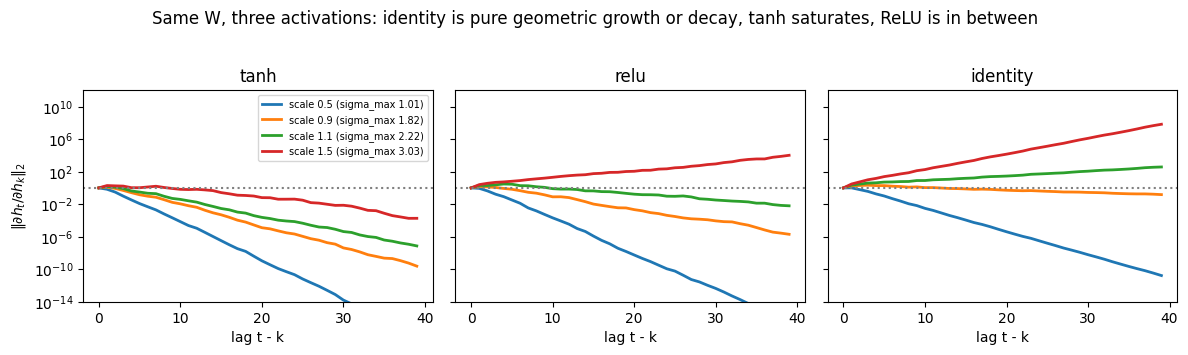

In [18]:
acts = {'tanh': torch.tanh, 'relu': torch.relu, 'identity': lambda a: a}
Wm = make_W(1.0, H6)
h_prev = torch.randn(H6, device=device) * 0.5
for name, f in acts.items():
    fn = lambda h: f(xs6[0] + Wm @ h)
    J_auto = jacobian(fn, h_prev)
    h_next = fn(h_prev)
    J_closed = {'tanh': torch.diag(1 - h_next ** 2) @ Wm,
                'relu': torch.diag((h_next > 0).float()) @ Wm,
                'identity': Wm}[name]
    assert torch.allclose(J_auto, J_closed, atol=1e-5), f'{name} Jacobian closed form is wrong'
    print(f'{name:>8}: closed-form Jacobian vs autograd  max |difference| = {(J_auto - J_closed).abs().max():.2e}'
          f'   |J|_2 = {torch.linalg.matrix_norm(J_closed, ord=2):.3f}')

act_scales = (0.5, 0.9, 1.1, 1.5)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, name in zip(axes, acts):
    for s in act_scales:
        Wm = make_W(s, H6)
        n = jacobian_product_norms(Wm, run_recurrence(Wm, xs6, act=name), act=name)
        ax.semilogy(range(len(n)), n, lw=2, label=f'scale {s} (sigma_max {spectral_stats(Wm)[0]:.2f})')
    ax.axhline(1, color='gray', ls=':'); ax.set_title(name); ax.set_xlabel('lag t - k')
axes[0].set_ylabel(r'$\|\partial h_t/\partial h_k\|_2$'); axes[0].legend(fontsize=7); axes[0].set_ylim(1e-14, 1e12)
fig.suptitle('Same W, three activations: identity is pure geometric growth or decay, tanh saturates, ReLU is in between', y=1.03)
plt.tight_layout(); plt.show()


### Widget 3: activation and scale

Pick an activation and drag `scale`. For `identity` the curve is a straight line on the log axis with slope
$\log\rho(W)$: a scale just below 1 keeps a 40-step lag alive, a scale just above blows it up, and nothing
damps either. For `tanh` the curve bends over at large scale as the units saturate, so it explodes much
later than the identity. For `relu` the curve is jagged: every unit that switches off removes a row from the
Jacobian, which is what makes ReLU RNNs both quick to explode and easy to kill.


In [19]:
def activation_widget(activation='tanh', scale=1.1):
    Wm = make_W(scale, H6)
    smax, rho = spectral_stats(Wm)
    n = jacobian_product_norms(Wm, run_recurrence(Wm, xs6, act=activation), act=activation)
    lags = np.arange(len(n))
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.semilogy(lags, n, lw=2, label=f'measured ({activation})')
    ax.semilogy(lags, smax ** lags, 'k--', lw=1, label=r'$\sigma_{\max}^{\,t-k}$')
    ax.axhline(1, color='gray', ls=':'); ax.set_ylim(1e-14, 1e12)
    ax.set_xlabel('lag t - k'); ax.set_ylabel(r'$\|\partial h_t/\partial h_k\|_2$'); ax.legend()
    ax.set_title(f'{activation}, scale {scale:.2f}: norm at lag 40 = {n[-1]:.2e}')
    plt.tight_layout(); plt.show()

interact(activation_widget,
         activation=Dropdown(options=['tanh', 'relu', 'identity'], value='tanh'),
         scale=FloatSlider(min=0.25, max=2.5, step=0.05, value=1.1, continuous_update=False));


interactive(children=(Dropdown(description='activation', options=('tanh', 'relu', 'identity'), value='tanh'), …

## 8. Truncated BPTT

Full BPTT stores every state of the sequence and runs the backward sweep over all of it, which for a long
stream (a language model over a book, a video) is neither affordable nor, given section 6, useful: the terms
from the distant past have vanished anyway. **Truncated BPTT** with parameters $(k_1, k_2)$ (Williams and
Peng, 1990; the notation is from Sutskever's thesis) processes the sequence in chunks of $k_1$ steps and,
at the end of each chunk, propagates the chunk's errors back for at most $k_2$ steps. $k_1 = 1$, $k_2 = T$
is full BPTT; $k_1 = k_2$ is the common "detach the state between chunks" scheme.

We implement it as a small change to `bptt_backward`: the running $\delta$ is reset at chunk boundaries
and the backward sweep for each chunk stops after $k_2$ steps. Two checks pin it down: with $k_2 = T$ it
must equal full BPTT, and with $k_1 = k_2$ it must equal autograd run on a forward pass that detaches
$h$ between chunks (for $k_1$ dividing $T$; a final partial chunk still looks back $k_2$ steps).


In [20]:
def bptt_truncated(P, xs, ys, k1, k2):
    '''Truncated BPTT(k1, k2): every k1 steps, backpropagate the errors of that chunk k2 steps back.
    Gradients for U, W, V, b, c of E = sum_t E_t (only the recurrent paths are cut).'''
    Pd = {k: v.detach() for k, v in P.items()}
    hs, logits = rnn_forward(Pd, xs)
    Tn, Cn = logits.shape
    g = {k: torch.zeros_like(v) for k, v in Pd.items()}
    chunk_ends = list(range(k1 - 1, Tn, k1))
    if chunk_ends[-1] != Tn - 1:
        chunk_ends.append(Tn - 1)                        # a final partial chunk
    for i, end in enumerate(chunk_ends):
        start = chunk_ends[i - 1] + 1 if i > 0 else 0    # steps whose own errors belong to this chunk
        delta = torch.zeros_like(hs[0])
        for k in range(end, max(end - k2, -1), -1):      # at most k2 steps back from the chunk end
            if k >= start:                               # this step's error is part of the chunk
                dz = torch.softmax(logits[k], dim=0) - F.one_hot(ys[k], Cn).float()
                g['V'] += torch.outer(dz, hs[k]); g['c'] += dz
                delta = delta + Pd['V'].t() @ dz
            local = (1 - hs[k] ** 2) * delta
            h_prev = hs[k - 1] if k > 0 else torch.zeros_like(hs[k])
            g['W'] += torch.outer(local, h_prev); g['U'] += torch.outer(local, xs[k]); g['b'] += local
            delta = Pd['W'].t() @ local
    return g

def autograd_detached_chunks(P, xs, ys, k):
    '''Reference for k1 = k2 = k: forward in chunks of k steps, detaching h between chunks.'''
    h = torch.zeros(P['W'].shape[0], device=xs.device)
    loss = 0.0
    for s in range(0, len(xs), k):
        hs_c, logits_c = rnn_forward(P, xs[s:s + k], h0=h.detach())
        loss = loss + sum(F.cross_entropy(logits_c[i][None], ys[s + i][None]) for i in range(len(hs_c)))
        h = hs_c[-1]
    return dict(zip('UWVbc', torch.autograd.grad(loss, [P[n] for n in 'UWVbc'])))

D8, H8, C8, T8 = 3, 16, 4, 30
P8 = init_params(D8, H8, C8, w_scale=1.0 / math.sqrt(H8), seed=5)
set_seed(6)
xs8 = torch.randn(T8, D8, device=device); ys8 = torch.randint(0, C8, (T8,), device=device)

g_full, _ = bptt_backward(P8, xs8, ys8)
g_t = bptt_truncated(P8, xs8, ys8, k1=1, k2=T8)
for n in 'UWVbc':
    assert torch.allclose(g_full[n], g_t[n], atol=1e-5), f'k2 = T should equal full BPTT for {n}'
print('k1 = 1, k2 = T reproduces full BPTT for all five parameters')

for k in (1, 5, 10):
    g_ref = autograd_detached_chunks(P8, xs8, ys8, k)
    g_t = bptt_truncated(P8, xs8, ys8, k1=k, k2=k)
    for n in 'UWVbc':
        assert torch.allclose(g_ref[n], g_t[n], atol=1e-5), f'k1 = k2 = {k} disagrees with detached autograd for {n}'
    print(f'k1 = k2 = {k}: matches autograd with detached chunks, max |diff| on W = {(g_ref["W"] - g_t["W"]).abs().max():.2e}')


k1 = 1, k2 = T reproduces full BPTT for all five parameters
k1 = k2 = 1: matches autograd with detached chunks, max |diff| on W = 1.91e-06
k1 = k2 = 5: matches autograd with detached chunks, max |diff| on W = 1.91e-06
k1 = k2 = 10: matches autograd with detached chunks, max |diff| on W = 2.86e-06


How much of the gradient does truncation throw away? We measure the relative error
$\|g_{k_1,k_2} - g_{\text{full}}\| / \|g_{\text{full}}\|$ for $W$ as a function of $k_2$, for three scales of
$W$ and $k_1 = 1$. With a small $W$ a few steps of history capture the gradient almost exactly (the rest
had vanished); with a large $W$ the truncated gradient stays far from the full one until $k_2$ is close
to half of $T$ (below 1% only from $k_2 = 13$ of 30 at scale 2), because the terms from far back are the
large ones.


W scale 0.5: relative error 0.245 at k2 = 1, 0.002 at k2 = 5, 1.28e-06 at k2 = 10; below 1% from k2 = 4
W scale 1.0: relative error 0.462 at k2 = 1, 0.025 at k2 = 5, 7.56e-04 at k2 = 10; below 1% from k2 = 7
W scale 2.0: relative error 0.816 at k2 = 1, 0.216 at k2 = 5, 2.85e-02 at k2 = 10; below 1% from k2 = 13


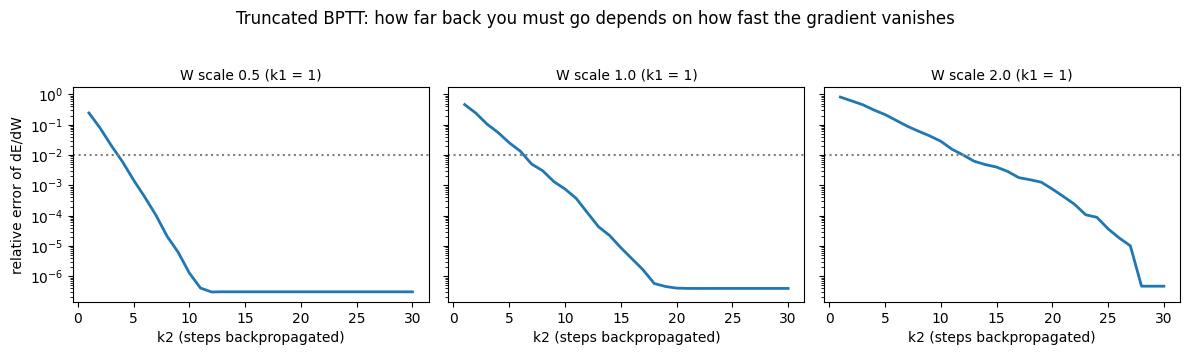

In [21]:
def truncation_error_curve(w_scale, k1, seed=5):
    '''Relative error of the truncated dE/dW against full BPTT, for k2 = 1 .. T.'''
    Pk = init_params(D8, H8, C8, w_scale=w_scale / math.sqrt(H8), seed=seed)
    g_full, _ = bptt_backward(Pk, xs8, ys8)
    errs = []
    for k2 in range(1, T8 + 1):
        g_t = bptt_truncated(Pk, xs8, ys8, k1=k1, k2=k2)
        errs.append(((g_t['W'] - g_full['W']).norm() / g_full['W'].norm()).item())
    return errs

trunc_scales = (0.5, 1.0, 2.0)
trunc_k1s = (1, 2, 5, 10)
trunc_curves = {(s, k1): truncation_error_curve(s, k1) for s in trunc_scales for k1 in trunc_k1s}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, s in zip(axes, trunc_scales):
    e = trunc_curves[(s, 1)]
    ax.semilogy(range(1, T8 + 1), e, lw=2)
    ax.set_title(f'W scale {s} (k1 = 1)', fontsize=10); ax.set_xlabel('k2 (steps backpropagated)')
    k_1pct = next((k for k, v in enumerate(e, 1) if v < 0.01), None)
    ax.axhline(0.01, color='gray', ls=':')
    print(f'W scale {s}: relative error {e[0]:.3f} at k2 = 1, {e[4]:.3f} at k2 = 5, {e[9]:.2e} at k2 = 10;'
          f' below 1% from k2 = {k_1pct}')
axes[0].set_ylabel('relative error of dE/dW')
fig.suptitle('Truncated BPTT: how far back you must go depends on how fast the gradient vanishes', y=1.03)
plt.tight_layout(); plt.show()


### Widget 4: the truncation parameters

Drag `k2` and watch the error against full BPTT, and switch `k1` to see the cost of processing longer
chunks: for a fixed $k_2$ a larger $k_1$ means the steps at the start of each chunk see fewer than $k_2$
steps of history, so the error goes up. The curves are precomputed on the model above.


In [22]:
def truncation_widget(w_scale=1.0, k1=1, k2=5):
    e = trunc_curves[(w_scale, k1)]
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.semilogy(range(1, T8 + 1), e, lw=2, color='tab:blue')
    ax.plot([k2], [e[k2 - 1]], 'o', color='tab:red', ms=9)
    ax.axhline(0.01, color='gray', ls=':')
    ax.set_xlabel('k2'); ax.set_ylabel('relative error of dE/dW vs full BPTT')
    ax.set_title(f'W scale {w_scale}, k1 = {k1}, k2 = {k2}: relative error {e[k2 - 1]:.3e}')
    plt.tight_layout(); plt.show()

interact(truncation_widget,
         w_scale=Dropdown(options=list(trunc_scales), value=1.0),
         k1=Dropdown(options=list(trunc_k1s), value=1),
         k2=IntSlider(min=1, max=T8, step=1, value=5));


interactive(children=(Dropdown(description='w_scale', index=1, options=(0.5, 1.0, 2.0), value=1.0), Dropdown(d…

## 9. Exploding gradients and gradient clipping

> "What if weights are high? Could lead to the exploding gradients problem. This, however, is not much of a
> problem; why? Will show up as NaN during implementation. Gradient clipping works!"

Exploding gradients are the $\gamma\sigma_{\max}(W) > 1$ side of section 6. They are the easier problem
because they are loud (a loss that jumps, weights that overflow to `NaN`) and because a one-line fix
exists. **Gradient clipping** (Pascanu et al., 2013) rescales the whole gradient vector whenever its norm
exceeds a threshold $\theta$:

$$g \leftarrow \frac{\theta}{\|g\|}\,g \quad \text{if } \|g\| > \theta$$

The direction is kept; only the step length is capped. We implement it from scratch and check against
`torch.nn.utils.clip_grad_norm_`, which clips the concatenated gradient of all parameters by its total norm.


In [23]:
def clip_by_norm(grads, threshold):
    '''Pascanu et al. clipping: rescale the list of gradient tensors so their joint norm is at most threshold.
    Returns the rescaled gradients and the norm before clipping.'''
    total = torch.sqrt(sum((g ** 2).sum() for g in grads))
    scale = min(1.0, threshold / (total.item() + 1e-12))
    return [g * scale for g in grads], total.item()

g = torch.tensor([30.0, 40.0], device=device)         # norm 50, far too large
clipped, before = clip_by_norm([g], threshold=5.0)
print(f'gradient {g.tolist()} has norm {before:.1f}; after clipping at 5: {[round(v, 3) for v in clipped[0].tolist()]}, norm {clipped[0].norm():.1f}')
assert abs(clipped[0].norm().item() - 5.0) < 1e-5

# Against PyTorch: clip the joint gradient of a small model.
set_seed(0)
model = nn.RNN(4, 32, batch_first=True).to(device)
x_probe = torch.randn(8, 12, 4, device=device)
model(x_probe)[0].pow(2).sum().backward()
ours, before = clip_by_norm([p.grad.clone() for p in model.parameters()], threshold=1.0)
torch_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
for o, p in zip(ours, model.parameters()):
    assert torch.allclose(o, p.grad, atol=1e-6), 'clip_by_norm disagrees with clip_grad_norm_'
print(f'joint gradient norm before clipping: ours {before:.3f}, torch {torch_norm:.3f};  clipped tensors agree')
print('direction is preserved, only the magnitude is capped')


gradient [30.0, 40.0] has norm 50.0; after clipping at 5: [3.0, 4.0], norm 5.0
joint gradient norm before clipping: ours 401.600, torch 401.600;  clipped tensors agree
direction is preserved, only the magnitude is capped


### 9.a A task that needs long memory

To see clipping matter we need a task where the gradient has to travel far. **Remember the first token**:
a sequence of $T$ one-hot tokens from a vocabulary of 4, the label is the first token, and the network must
report it after reading the remaining $T - 1$ tokens, which are random distractors from the same
vocabulary. Chance is 25%. The only useful signal is $\partial E/\partial h_0$, the error pushed back to the
first step through $T - 1$ Jacobian factors; it feeds the $k = 0$ term of $\partial E/\partial U$ (and the
$k = 1$ term of $\partial E/\partial W$; the $k = 0$ term of $\partial E/\partial W$ is zero, as section 5 showed). The model is `nn.RNN` (verified against our forward pass in
section 1) with $H = 32$ and a linear read-out at the last step, trained with plain SGD.


In [24]:
K_VOCAB, H9 = 4, 32

def make_batch(B, T, seed=None):
    '''B sequences of T one-hot tokens; the label is the first token.'''
    gen = torch.Generator().manual_seed(seed) if seed is not None else None
    tok = torch.randint(0, K_VOCAB, (B, T), generator=gen)
    return F.one_hot(tok, K_VOCAB).float().to(device), tok[:, 0].to(device)

class RememberRNN(nn.Module):
    '''nn.RNN with a read-out at the last step; W_hh is drawn as N(0, w_scale^2 / H) or set to identity.'''
    def __init__(self, H=32, w_scale=1.0, nonlinearity='tanh', init='gaussian'):
        super().__init__()
        self.rnn = nn.RNN(K_VOCAB, H, nonlinearity=nonlinearity, batch_first=True)
        self.out = nn.Linear(H, K_VOCAB)
        with torch.no_grad():
            if init == 'gaussian':
                self.rnn.weight_hh_l0.copy_(torch.randn(H, H) * w_scale / math.sqrt(H))
            elif init == 'identity':
                self.rnn.weight_hh_l0.copy_(torch.eye(H) * w_scale)
            elif init == 'orthogonal':
                nn.init.orthogonal_(self.rnn.weight_hh_l0, gain=w_scale)
    def forward(self, x):
        hs, _ = self.rnn(x)
        return self.out(hs[:, -1])

def train_remember(T, clip=None, steps=600, lr=0.5, w_scale=1.0, seed=0, B=64, nonlinearity='tanh',
                   init='gaussian', record_W=False):
    '''SGD on the remember-the-first-token task. clip=None disables clipping.
    Returns test accuracy and per-step histories (loss, gradient norm before clipping, sigma_max(W_hh)).'''
    set_seed(seed)
    m = RememberRNN(H9, w_scale, nonlinearity, init).to(device)
    opt = torch.optim.SGD(m.parameters(), lr=lr)
    hist = {'loss': [], 'gnorm': [], 'smax': [], 'W': []}
    for s in range(steps):
        x, y = make_batch(B, T)
        loss = F.cross_entropy(m(x), y)
        opt.zero_grad(); loss.backward()
        gn = nn.utils.clip_grad_norm_(m.parameters(), clip if clip is not None else float('inf')).item()
        hist['loss'].append(loss.item()); hist['gnorm'].append(gn)
        if record_W:
            hist['smax'].append(torch.linalg.matrix_norm(m.rnn.weight_hh_l0.detach(), ord=2).item())
            hist['W'].append(m.rnn.weight_hh_l0.detach().clone())
        if not math.isfinite(loss.item()):
            break
        opt.step()
    x, y = make_batch(1000, T, seed=123)
    with torch.no_grad():
        acc = (m(x).argmax(1) == y).float().mean().item()
    return acc, hist, m

x_demo, y_demo = make_batch(2, 8, seed=0)
print('two sequences of T = 8 tokens (token ids):', npy(x_demo.argmax(-1)).tolist(), ' labels:', y_demo.tolist())

t0 = time.time()
acc_free, hist_free, _ = train_remember(T=15, clip=None, record_W=True)
acc_clip, hist_clip, _ = train_remember(T=15, clip=1.0, record_W=True)
print(f'\nT = 15, 600 SGD steps ({time.time() - t0:.1f} s):')
print(f'  without clipping: test accuracy {acc_free:.3f}, largest gradient norm {max(hist_free["gnorm"]):.1f}, final loss {hist_free["loss"][-1]:.3f}')
print(f'  with clipping at 1.0: test accuracy {acc_clip:.3f}, largest gradient norm {max(hist_clip["gnorm"]):.1f}, final loss {hist_clip["loss"][-1]:.3f}')
print(f'  steps where the norm exceeded 1.0 (clipped run): {sum(g > 1.0 for g in hist_clip["gnorm"])} of {len(hist_clip["gnorm"])}')
s_bad = int(np.argmax(hist_free['gnorm']))            # the unclipped step with the largest gradient norm
print(f'  unclipped run, sigma_max(W_hh): {hist_free["smax"][0]:.2f} at initialization, '
      f'{hist_free["smax"][s_bad]:.2f} just before step {s_bad} (gradient norm {hist_free["gnorm"][s_bad]:.1f}), '
      f'{hist_free["smax"][s_bad + 1]:.2f} right after it')


two sequences of T = 8 tokens (token ids): [[0, 3, 1, 0, 3, 3, 3, 3], [1, 3, 1, 2, 0, 3, 2, 0]]  labels: [0, 1]



T = 15, 600 SGD steps (1.3 s):
  without clipping: test accuracy 0.232, largest gradient norm 237.0, final loss 5.900
  with clipping at 1.0: test accuracy 1.000, largest gradient norm 4.8, final loss 0.000
  steps where the norm exceeded 1.0 (clipped run): 51 of 600
  unclipped run, sigma_max(W_hh): 1.85 at initialization, 6.51 just before step 66 (gradient norm 237.0), 51.91 right after it


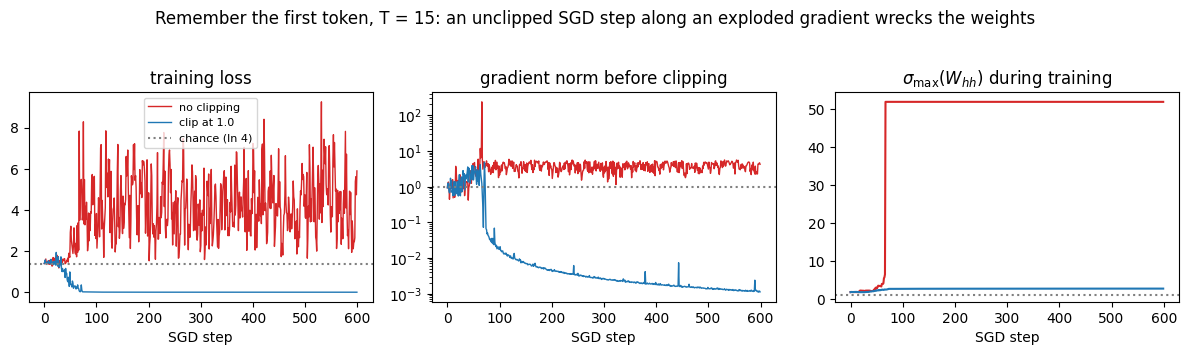

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for h, name, col in ((hist_free, 'no clipping', 'tab:red'), (hist_clip, 'clip at 1.0', 'tab:blue')):
    axes[0].plot(h['loss'], color=col, lw=1, label=name)
    axes[1].semilogy(h['gnorm'], color=col, lw=1, label=name)
    axes[2].plot(h['smax'], color=col, lw=1.5, label=name)
axes[0].axhline(math.log(K_VOCAB), color='gray', ls=':', label='chance (ln 4)')
axes[0].set_title('training loss'); axes[0].set_xlabel('SGD step'); axes[0].legend(fontsize=8)
axes[1].axhline(1.0, color='gray', ls=':'); axes[1].set_title('gradient norm before clipping'); axes[1].set_xlabel('SGD step')
axes[2].axhline(1.0, color='gray', ls=':'); axes[2].set_title(r'$\sigma_{\max}(W_{hh})$ during training'); axes[2].set_xlabel('SGD step')
fig.suptitle('Remember the first token, T = 15: an unclipped SGD step along an exploded gradient wrecks the weights', y=1.03)
plt.tight_layout(); plt.show()


The unclipped run does not reach `NaN`: tanh keeps the hidden state bounded, so instead of overflowing, the
loss jumps to values well above chance (a cross-entropy of 4 means the network is confidently wrong) right
after one step whose gradient norm was in the hundreds. With $\eta = 0.5$ that single step moves $W_{hh}$
by a matrix of norm about 100, and $\sigma_{\max}(W_{hh})$ jumps from 6.5 just before that step (it had
already drifted up from 1.85 at initialization) to 52 right after it (the right panel).
From then on every unit is saturated, the loss never recovers, and the gradient norm stays in the single
digits because a saturated network has almost no gradient to give. The clipped run sees the same early
spikes in the raw gradient norm but takes steps of length at most $1.0 \cdot \eta$, and it solves the task.

### 9.b Accuracy against the lag $T$

The claim to measure is that clipping rescues training on long lags. We train for $T \in \{5, 10, 15, 20, 30\}$
with and without clipping, three seeds each, and report the mean test accuracy.


30 training runs in 11.4 s

   T            no clipping            clip at 1.0
   5    1.000  [1.0, 1.0, 1.0]    1.000  [1.0, 1.0, 1.0]
  10    0.588  [0.52, 0.25, 1.0]    1.000  [1.0, 1.0, 1.0]
  15    0.317  [0.23, 0.48, 0.24]    1.000  [1.0, 1.0, 1.0]
  20    0.259  [0.24, 0.27, 0.27]    1.000  [1.0, 1.0, 1.0]
  30    0.252  [0.24, 0.26, 0.26]    0.311  [0.24, 0.24, 0.45]


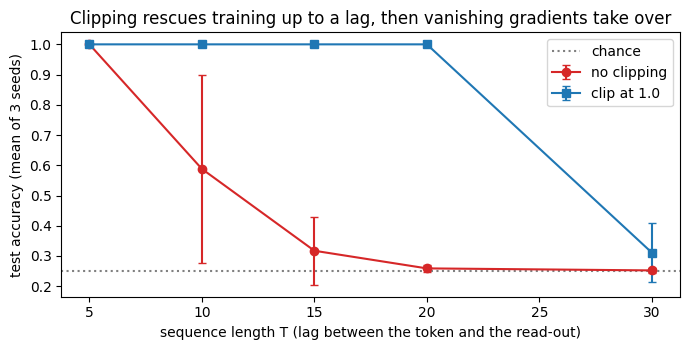

In [26]:
T_grid = [5, 10, 15, 20, 30]
seeds = (0, 1, 2)
t0 = time.time()
acc_table = {}
for T_len in T_grid:
    for clip in (None, 1.0):
        accs = [train_remember(T_len, clip=clip, seed=s)[0] for s in seeds]
        acc_table[(T_len, clip)] = accs
print(f'{len(T_grid) * 2 * len(seeds)} training runs in {time.time() - t0:.1f} s\n')
print(f'{"T":>4} {"no clipping":>22} {"clip at 1.0":>22}')
for T_len in T_grid:
    a0, a1 = acc_table[(T_len, None)], acc_table[(T_len, 1.0)]
    print(f'{T_len:>4} {np.mean(a0):>8.3f}  {str([round(a, 2) for a in a0]):>12} {np.mean(a1):>8.3f}  {str([round(a, 2) for a in a1]):>12}')

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.errorbar(T_grid, [np.mean(acc_table[(T_len, None)]) for T_len in T_grid],
            yerr=[np.std(acc_table[(T_len, None)]) for T_len in T_grid], marker='o', color='tab:red', label='no clipping', capsize=3)
ax.errorbar(T_grid, [np.mean(acc_table[(T_len, 1.0)]) for T_len in T_grid],
            yerr=[np.std(acc_table[(T_len, 1.0)]) for T_len in T_grid], marker='s', color='tab:blue', label='clip at 1.0', capsize=3)
ax.axhline(0.25, color='gray', ls=':', label='chance')
ax.set_xlabel('sequence length T (lag between the token and the read-out)'); ax.set_ylabel('test accuracy (mean of 3 seeds)')
ax.set_title('Clipping rescues training up to a lag, then vanishing gradients take over'); ax.legend()
plt.tight_layout(); plt.show()


Read the table with the two regimes of section 6 in mind. At short lags nothing explodes and both
runs learn. In the middle the unclipped runs fall to chance because occasional exploded gradients wreck the
weights, while clipping keeps every run at 100%. At $T = 30$ clipping no longer helps: $\partial E/\partial h_0$, the error pushed back to the
first step, has vanished before it can feed the $k = 0$ term of $\partial E/\partial U$, and there is no bad
step to prevent. This is the slide's point in one figure:
exploding gradients are "not much of a problem" because clipping works, and vanishing gradients are the
problem that needs the next lecture.

### 9.c How tight should the threshold be?

We sweep $\theta$ at $T = 10$, a lag where the unclipped run fails. The static figure shows the loss curves;
the widget lets you flip through them one at a time.


 threshold  accuracy  max grad norm  steps clipped  final loss
      None     0.519           12.2              0       0.872
       0.1     1.000           15.0            377       0.001
       0.3     1.000            8.2            121       0.001
       1.0     1.000            4.9             39       0.000
       3.0     1.000            3.9              9       0.000
      10.0     0.508           12.6              3       2.314


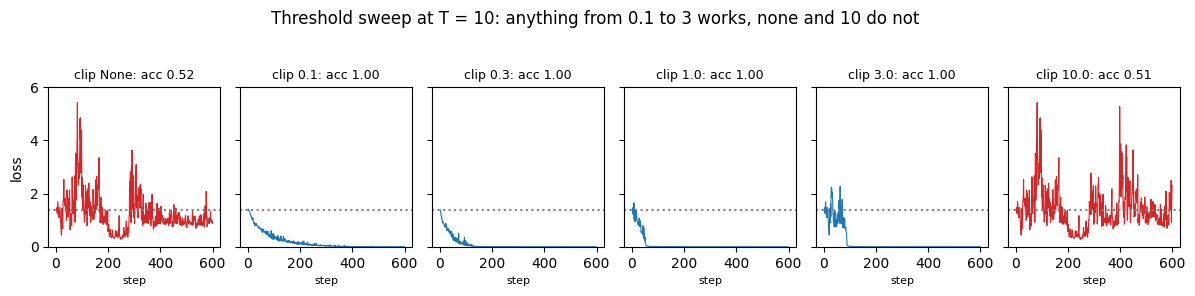

In [27]:
thresholds = [None, 0.1, 0.3, 1.0, 3.0, 10.0]
thr_runs = {thr: train_remember(T=10, clip=thr, seed=0) for thr in thresholds}
print(f'{"threshold":>10} {"accuracy":>9} {"max grad norm":>14} {"steps clipped":>14} {"final loss":>11}')
for thr, (acc, h, _) in thr_runs.items():
    n_clip = sum(g > thr for g in h['gnorm']) if thr is not None else 0
    print(f'{str(thr):>10} {acc:>9.3f} {max(h["gnorm"]):>14.1f} {n_clip:>14d} {h["loss"][-1]:>11.3f}')

fig, axes = plt.subplots(1, len(thresholds), figsize=(12, 2.8), sharey=True)
for ax, (thr, (acc, h, _)) in zip(axes, thr_runs.items()):
    ax.plot(h['loss'], lw=0.8, color='tab:red' if acc < 0.9 else 'tab:blue')
    ax.axhline(math.log(K_VOCAB), color='gray', ls=':')
    ax.set_title(f'clip {thr}: acc {acc:.2f}', fontsize=9); ax.set_xlabel('step', fontsize=8)
axes[0].set_ylabel('loss'); axes[0].set_ylim(0, 6)
fig.suptitle('Threshold sweep at T = 10: anything from 0.1 to 3 works, none and 10 do not', y=1.04)
plt.tight_layout(); plt.show()


### Widget 5: the clipping threshold

Select a threshold. A very small $\theta$ turns most steps into normalized-gradient steps (377 of 600 at
$\theta = 0.1$ in the table above) and still learns, just more slowly; a threshold of 10 lets the
occasional exploded step through and the run collapses like the unclipped one. The runs are precomputed
above.


In [28]:
def threshold_widget(threshold='1.0'):
    thr = None if threshold == 'none' else float(threshold)
    acc, h, _ = thr_runs[thr]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    axes[0].plot(h['loss'], lw=0.8); axes[0].axhline(math.log(K_VOCAB), color='gray', ls=':')
    axes[0].set_ylim(0, 6); axes[0].set_xlabel('SGD step'); axes[0].set_title(f'loss, test accuracy {acc:.3f}')
    axes[1].semilogy(h['gnorm'], lw=0.8); axes[1].set_xlabel('SGD step'); axes[1].set_title('gradient norm before clipping')
    if thr is not None:
        axes[1].axhline(thr, color='tab:red', ls='--', label=f'threshold {thr}'); axes[1].legend()
    fig.suptitle(f'T = 10, clipping threshold = {threshold}')
    plt.tight_layout(); plt.show()

interact(threshold_widget, threshold=Dropdown(options=['none', '0.1', '0.3', '1.0', '3.0', '10.0'], value='1.0'));


interactive(children=(Dropdown(description='threshold', index=3, options=('none', '0.1', '0.3', '1.0', '3.0', …

### 9.d Where the slide's `NaN` comes from

The tanh runs above blew up without producing `NaN` because tanh bounds the state. Replace the activation
by ReLU, whose state is unbounded, and start $W$ a little larger (scale 2.5, so $\sigma_{\max} \approx 5$),
and the slide's description is literal: the unclipped SGD run overflows within a handful of steps, while the
clipped run with the same start learns the $T = 10$ task.


In [29]:
acc_relu_free, h_relu_free, _ = train_remember(T=10, clip=None, nonlinearity='relu', w_scale=2.5, steps=300)
acc_relu_clip, h_relu_clip, _ = train_remember(T=10, clip=1.0, nonlinearity='relu', w_scale=2.5, steps=300)
first_bad = next((i for i, v in enumerate(h_relu_free['loss']) if not math.isfinite(v)), None)
print(f'ReLU RNN, T = 10, no clipping : losses of the first steps {[round(v, 2) if math.isfinite(v) else v for v in h_relu_free["loss"][:6]]}')
print(f'  first non-finite loss at step {first_bad}, largest finite gradient norm {max(g for g in h_relu_free["gnorm"] if math.isfinite(g)):.2e}')
print(f'ReLU RNN, T = 10, clip at 1.0 : all {len(h_relu_clip["loss"])} losses finite, test accuracy {acc_relu_clip:.3f}')
assert first_bad is not None, 'expected the unclipped ReLU run to overflow'
assert all(math.isfinite(v) for v in h_relu_clip['loss'])


ReLU RNN, T = 10, no clipping : losses of the first steps [5.16, 146.92, 5327161856.0, nan]
  first non-finite loss at step 3, largest finite gradient norm 5.57e+10
ReLU RNN, T = 10, clip at 1.0 : all 300 losses finite, test accuracy 1.000


### Widget 6: a training-step scrubber

The $T = 15$ runs of 9.a stored $W_{hh}$ at every step. Drag `step` to move through training and see, at
that moment, the loss and gradient-norm history so far, and the Jacobian-product norm
$\|\partial h_t/\partial h_k\|$ over the lag computed from the stored $W_{hh}$ on a fixed probe sequence.
In the unclipped run, find the step where the gradient norm spikes (the loss jumps at the same moment) and
watch $\sigma_{\max}(W_{hh})$ jump with it; from then on the Jacobian product *decays* over the lag, because
a $W$ that large saturates every unit and $1 - h^2 \approx 0$. In the clipped run the product grows with the
lag instead: to remember the first token the network needs $\|\partial h_t/\partial h_0\|$ large, and
clipping is what lets it live in that regime without SGD blowing up. The static figure shows four snapshots
of both runs.


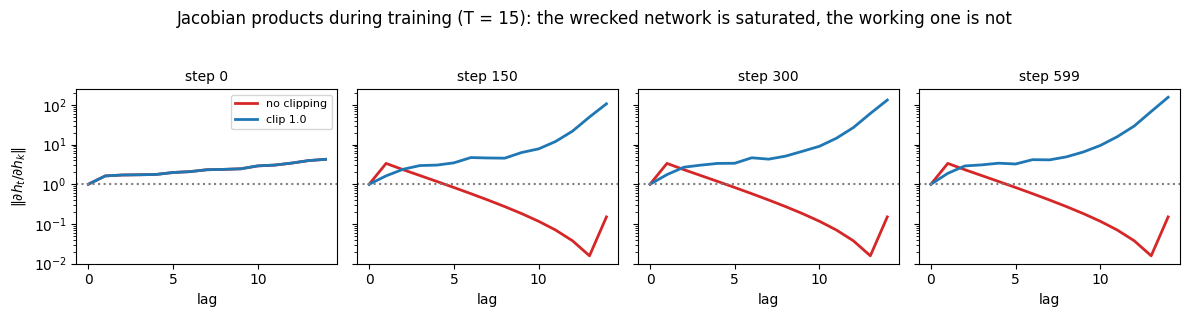

In [30]:
x_probe, _ = make_batch(1, 15, seed=7)
probe = x_probe[0]                                     # (15, 4) one-hot inputs

def snapshot_curve(model_hist, step):
    '''|dh_t/dh_k| over the lag, with W_hh as it was at `step` (input weights from a fresh probe model).'''
    Wm = model_hist['W'][step]
    U_probe = torch.eye(H9, K_VOCAB, device=device)   # a fixed, simple input projection for the probe
    hs_p = run_recurrence(Wm, probe @ U_probe.t())
    return jacobian_product_norms(Wm, hs_p)

snap_steps = [0, 150, 300, 599]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.0), sharey=True)
for ax, s in zip(axes, snap_steps):
    for h, name, col in ((hist_free, 'no clipping', 'tab:red'), (hist_clip, 'clip 1.0', 'tab:blue')):
        n = snapshot_curve(h, s)
        ax.semilogy(range(len(n)), n, color=col, lw=2, label=name)
    ax.axhline(1, color='gray', ls=':'); ax.set_title(f'step {s}', fontsize=10); ax.set_xlabel('lag')
axes[0].set_ylabel(r'$\|\partial h_t/\partial h_k\|$'); axes[0].legend(fontsize=8)
fig.suptitle('Jacobian products during training (T = 15): the wrecked network is saturated, the working one is not', y=1.04)
plt.tight_layout(); plt.show()


Now the same thing under your control. Drag `step` through training and switch `run` to compare the two.

In [31]:
def scrubber(step=0, run='no clipping'):
    h = hist_free if run == 'no clipping' else hist_clip
    step = min(step, len(h['loss']) - 1)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
    axes[0].plot(h['loss'][:step + 1], color='tab:red', lw=1); axes[0].set_xlim(0, 600); axes[0].set_ylim(0, 6)
    axes[0].axhline(math.log(K_VOCAB), color='gray', ls=':'); axes[0].set_title(f'loss up to step {step}: {h["loss"][step]:.3f}')
    axes[1].semilogy(h['gnorm'][:step + 1], color='tab:red', lw=1); axes[1].set_xlim(0, 600); axes[1].set_ylim(1e-3, 1e3)
    axes[1].axhline(1.0, color='gray', ls=':'); axes[1].set_title(f'grad norm at this step: {h["gnorm"][step]:.2f}')
    n = snapshot_curve(h, step)
    axes[2].semilogy(range(len(n)), n, color='tab:blue', lw=2); axes[2].set_ylim(1e-8, 1e6)
    axes[2].axhline(1, color='gray', ls=':'); axes[2].set_xlabel('lag')
    axes[2].set_title(f'Jacobian product now (sigma_max = {h["smax"][step]:.2f})')
    fig.suptitle(f'{run}, T = 15, step {step}')
    plt.tight_layout(); plt.show()

interact(scrubber,
         step=IntSlider(min=0, max=599, step=1, value=0, continuous_update=False),
         run=Dropdown(options=['no clipping', 'clip at 1.0'], value='no clipping'));


interactive(children=(IntSlider(value=0, continuous_update=False, description='step', max=599), Dropdown(descr…

## 10. The slide's homework, answered

> "In the next lecture, we'll see architectures that tackle the vanishing gradient problem reasonably well;
> meanwhile, can you think of simpler solutions (preferably those which don't change the RNN architecture)?"

The review slide of the next lecture lists the answers: **use ReLU; regularization; better initialization
of weights; use only short time sequences**. Each maps onto something measured above.

- **Short sequences** is truncated BPTT (section 8): if the gradient from far back has vanished, stop
  computing it. It is a fix for cost, not for memory; the network still cannot learn a dependency longer
  than $k_2$.
- **ReLU** removes the $1 - h^2$ damping (section 7). On a surviving path the factor is exactly $W$, so with
  a well-scaled $W$ the gradient neither shrinks nor grows. The price is section 9.d: nothing bounds the state.
- **Better initialization** means choosing $W$ so that $\sigma_{\max}(W) \approx 1$ and, better, so that
  $W$ preserves norms in every direction: the identity (Le, Jaitly and Hinton, 2015, the "IRNN") or an
  orthogonal matrix. A Gaussian $W$ with $\sigma_{\max} = 1$ has most singular values well below 1, so most
  directions still decay.
- **Regularization** in Pascanu et al. is a penalty that keeps $\|\partial E/\partial h_k\|$ from shrinking as it
  travels back; we do not implement it here, but the reach-back measurement below is exactly the quantity it
  regularizes.

We measure how far the gradient reaches back at initialization for four choices, on the remember task at
$T = 30$, and then retrain at $T = 30$, where section 9 failed, combining activation, initialization and
clipping, with a smaller learning rate ($\eta = 0.05$) and more steps (1500) so that the slow, small
gradient from the first token has time to act.


               configuration  sigma_max(W)  |dE/dh_29|   |dE/dh_0|      ratio
    tanh, Gaussian (scale 1)         1.847    1.70e-02    7.18e-03   4.22e-01
         tanh, identity init         1.000    1.75e-02    2.10e-03   1.20e-01
       tanh, orthogonal init         1.000    1.69e-02    1.49e-03   8.82e-02
  relu, identity init (IRNN)         1.000    1.81e-02    1.11e-02   6.13e-01


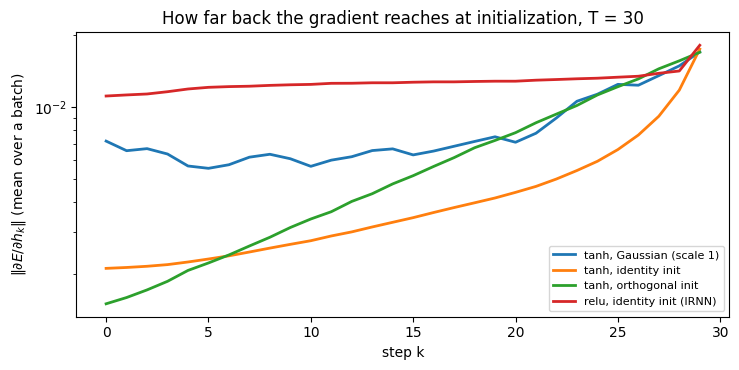

In [32]:
def reachback_model(m, T=30, seed=11):
    '''|dE/dh_k| for every k on one batch, for a RememberRNN: how far back the loss can see.
    The recurrence is unrolled by hand with the module's weights so that every state is a graph node
    (nn.RNN's fused kernel only exposes its output tensor, not the states inside the recurrence).'''
    x, y = make_batch(32, T, seed=seed)
    f = torch.tanh if m.rnn.nonlinearity == 'tanh' else torch.relu
    W_ih, W_hh, b_ih, b_hh = m.rnn.weight_ih_l0, m.rnn.weight_hh_l0, m.rnn.bias_ih_l0, m.rnn.bias_hh_l0
    h = torch.zeros(x.shape[0], W_hh.shape[0], device=device); states = []
    for t in range(T):
        h = f(x[:, t] @ W_ih.t() + b_ih + h @ W_hh.t() + b_hh); states.append(h)
    assert torch.allclose(torch.stack(states, 1), m.rnn(x)[0], atol=1e-5), 'hand unroll disagrees with nn.RNN'
    loss = F.cross_entropy(m.out(states[-1]), y)
    grads = torch.autograd.grad(loss, states)
    return [g.norm(dim=1).mean().item() for g in grads]

configs = [('tanh, Gaussian (scale 1)', dict(nonlinearity='tanh', init='gaussian', w_scale=1.0)),
           ('tanh, identity init', dict(nonlinearity='tanh', init='identity', w_scale=1.0)),
           ('tanh, orthogonal init', dict(nonlinearity='tanh', init='orthogonal', w_scale=1.0)),
           ('relu, identity init (IRNN)', dict(nonlinearity='relu', init='identity', w_scale=1.0))]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
print(f'{"configuration":>28} {"sigma_max(W)":>13} {"|dE/dh_29|":>11} {"|dE/dh_0|":>11} {"ratio":>10}')
for name, cfg in configs:
    set_seed(0)
    m = RememberRNN(H9, **cfg).to(device)
    r = reachback_model(m)
    smax = torch.linalg.matrix_norm(m.rnn.weight_hh_l0.detach(), ord=2).item()
    print(f'{name:>28} {smax:>13.3f} {r[-1]:>11.2e} {r[0]:>11.2e} {r[0] / r[-1]:>10.2e}')
    ax.semilogy(range(30), r, lw=2, label=name)
ax.set_xlabel('step k'); ax.set_ylabel(r'$\|\partial E/\partial h_k\|$ (mean over a batch)')
ax.set_title('How far back the gradient reaches at initialization, T = 30'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [33]:
t0 = time.time()
rows = [('tanh, Gaussian, clip 1.0, lr 0.5, 600 steps (section 9)', acc_table[(30, 1.0)], None)]
for name, cfg in (('tanh, Gaussian, clip 1.0', dict(init='gaussian', clip=1.0)),
                  ('tanh, identity, clip 1.0', dict(init='identity', clip=1.0)),
                  ('relu, Gaussian, clip 1.0', dict(init='gaussian', clip=1.0, nonlinearity='relu')),
                  ('relu, identity (IRNN), no clipping', dict(init='identity', clip=None, nonlinearity='relu')),
                  ('relu, identity (IRNN), clip 1.0', dict(init='identity', clip=1.0, nonlinearity='relu'))):
    runs = [train_remember(T=30, seed=s, lr=0.05, steps=1500, **cfg) for s in seeds]
    rows.append((name + ', lr 0.05, 1500 steps', [r[0] for r in runs],
                 max(g for r in runs for g in r[1]['gnorm'] if math.isfinite(g))))
print(f'T = 30, 3 seeds each ({time.time() - t0:.1f} s):')
print(f'{"configuration":>58} {"mean acc":>9} {"per seed":>20} {"max grad norm":>14}')
for name, accs, gmax in rows:
    print(f'{name:>58} {np.mean(accs):>9.3f} {str([round(a, 2) for a in accs]):>20} {"" if gmax is None else f"{gmax:.1e}":>14}')


T = 30, 3 seeds each (19.9 s):
                                             configuration  mean acc             per seed  max grad norm
   tanh, Gaussian, clip 1.0, lr 0.5, 600 steps (section 9)     0.311   [0.24, 0.24, 0.45]               
             tanh, Gaussian, clip 1.0, lr 0.05, 1500 steps     0.831     [1.0, 1.0, 0.49]        2.6e+03
             tanh, identity, clip 1.0, lr 0.05, 1500 steps     0.391   [0.26, 0.47, 0.44]        1.9e+02
             relu, Gaussian, clip 1.0, lr 0.05, 1500 steps     0.259   [0.25, 0.27, 0.25]        6.7e-01
   relu, identity (IRNN), no clipping, lr 0.05, 1500 steps     0.248   [0.26, 0.24, 0.24]        2.8e+07
      relu, identity (IRNN), clip 1.0, lr 0.05, 1500 steps     1.000      [1.0, 1.0, 1.0]        2.5e+02


The reach-back table says that at initialization none of the four choices has lost the first token yet:
across 30 steps the gradient shrinks by a factor of about 2 (IRNN) to about 10 (tanh with the identity or
orthogonal start, where the $1 - h^2$ factors erode the identity as soon as the units leave zero). The
difficulty at $T = 30$ is therefore not the initial reach but keeping it alive while SGD moves $W$, and that
is what the training table measures.

Three of the four homework answers show up there. A **smaller learning rate with more steps** (plus
clipping) already lifts the Gaussian tanh network from 31% in section 9 to solving $T = 30$ on two seeds of
three: the term from the first token is small, and a large $\eta$ lets the large recent terms swamp it and
push $W$ into saturation. **ReLU with the identity initialization**, the IRNN of Le, Jaitly and Hinton
(2015), solves $T = 30$ on every seed, because its Jacobian on active units is exactly $I$ and its reach-back
curve is the flattest of the four. The same IRNN **without clipping** stays at chance with gradient norms
in the tens of millions, so the two fixes are complementary: the initialization keeps the signal alive,
clipping keeps SGD from acting on the occasional blow-up. Two negative results are just as informative:
the identity initialization with tanh did not beat the Gaussian one, and ReLU with a Gaussian $W$ stayed
at chance with gradient norms that never exceeded 0.7, since half of its units are switched off at every
step and the signal that survives is too weak for $\eta = 0.05$ to use. None of the successful runs changed
the architecture; they changed where $W$ starts, how big a step SGD may take, and how long it runs. The
next lecture changes the architecture instead (LSTMs and GRUs), so that the gradient can travel far by
construction rather than by luck of initialization.


## 11. Explore and verify

Everything above was checked on the model it was built on. Here we rerun the checks on a fresh random
model of a different size, so the from-scratch BPTT, the truncation and the clipping are verified
independently of the numbers in the sections. Then the lecture's central picture, how far back the gradient
reaches as a function of the scale of $W$, is drawn as a static sweep and handed to a slider.


In [34]:
Dv, Hv, Cv, Tv = 5, 6, 3, 8
Pv = init_params(Dv, Hv, Cv, w_scale=0.8 / math.sqrt(Hv), seed=21)
set_seed(22)
xsv = torch.randn(Tv, Dv, device=device); ysv = torch.randint(0, Cv, (Tv,), device=device)

# 1. one-sweep BPTT for all five parameters vs autograd on E = sum_t E_t
hsv, logitsv = rnn_forward(Pv, xsv)
Ev = F.cross_entropy(logitsv, ysv, reduction='sum')
auto_v = dict(zip('UWVbc', torch.autograd.grad(Ev, [Pv[n] for n in 'UWVbc'])))
gv, delta_norms = bptt_backward(Pv, xsv, ysv)
worst = 0.0
for n in 'UWVbc':
    assert torch.allclose(auto_v[n], gv[n], atol=1e-5), f'fresh model: BPTT for {n} disagrees'
    worst = max(worst, (auto_v[n] - gv[n]).abs().max().item())
print(f'fresh model (D={Dv}, H={Hv}, C={Cv}, T={Tv}): BPTT vs autograd, worst max |difference| over U, W, V, b, c = {worst:.2e}')

# 2. the explicit slide formula, per t, summed, equals the sweep
gW_explicit = sum(bptt_explicit(Pv, xsv, ysv, t)[0] for t in range(Tv))
assert torch.allclose(gW_explicit, gv['W'], atol=1e-5)
print(f'explicit sum over k and t vs one sweep: max |difference| = {(gW_explicit - gv["W"]).abs().max():.2e}')

# 3. truncation: k2 = T is exact, k1 = k2 = 4 matches detached autograd
gt = bptt_truncated(Pv, xsv, ysv, 1, Tv)
assert all(torch.allclose(gt[n], gv[n], atol=1e-5) for n in 'UWVbc')
gref = autograd_detached_chunks(Pv, xsv, ysv, 4)
gt3 = bptt_truncated(Pv, xsv, ysv, 4, 4)
assert all(torch.allclose(gref[n], gt3[n], atol=1e-5) for n in 'UWVbc')
err3 = ((gt3['W'] - gv['W']).norm() / gv['W'].norm()).item()
print(f'truncation checks pass; BPTT(4, 4) drops {100 * err3:.1f}% of dE/dW on this model')

# 4. clipping from scratch vs torch on the fresh gradients
clipped_v, norm_v = clip_by_norm([gv[n] for n in 'UWVbc'], threshold=0.5)
joint = torch.sqrt(sum((g ** 2).sum() for g in clipped_v)).item()
assert abs(joint - min(0.5, norm_v)) < 1e-5
print(f'clipping: joint norm {norm_v:.4f} -> {joint:.4f} at threshold 0.5')
print(f'|delta_k| = |dE/dh_k| along the sweep, k = 0..{Tv - 1}: {[f"{v:.3f}" for v in delta_norms]}')


fresh model (D=5, H=6, C=3, T=8): BPTT vs autograd, worst max |difference| over U, W, V, b, c = 4.77e-07
explicit sum over k and t vs one sweep: max |difference| = 9.54e-07
truncation checks pass; BPTT(4, 4) drops 17.6% of dE/dW on this model
clipping: joint norm 27.1091 -> 0.5000 at threshold 0.5
|delta_k| = |dE/dh_k| along the sweep, k = 0..7: ['3.016', '3.356', '0.736', '2.552', '2.579', '5.866', '3.812', '3.234']


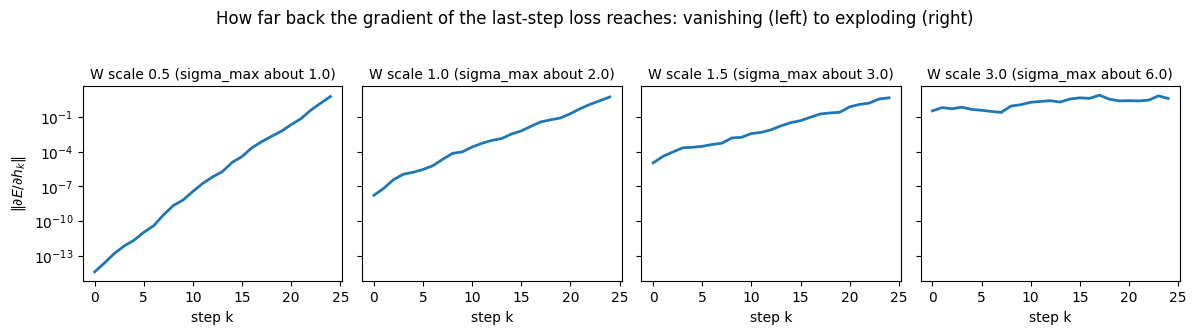

In [35]:
# Static sweep: gradient norm reaching back in time, for four recurrent weight scales.
def reachback(scale, T_unroll=25, seed=0, H_r=16):
    '''|dE/dh_k| for every k when the loss sits at the last step, for a random tanh RNN.'''
    set_seed(seed)
    Ul = torch.randn(H_r, D, device=device); Wl = torch.randn(H_r, H_r, device=device) * scale / math.sqrt(H_r)
    Vl = torch.randn(C, H_r, device=device)
    Wl.requires_grad_(True)                          # so the states carry a graph to differentiate through
    xs_l = torch.randn(T_unroll, D, device=device)
    h = torch.zeros(H_r, device=device); states = []
    for x in xs_l:
        h = torch.tanh(Ul @ x + Wl @ h); states.append(h)
    loss = F.cross_entropy((Vl @ states[-1])[None], torch.tensor([0], device=device))
    grads = torch.autograd.grad(loss, states, allow_unused=True)
    return [g.norm().item() if g is not None else 0.0 for g in grads]

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2), sharey=True)
for ax, scale in zip(axes, [0.5, 1.0, 1.5, 3.0]):
    n = reachback(scale)
    ax.semilogy(range(len(n)), n, lw=2)
    ax.set_title(f'W scale {scale} (sigma_max about {2 * scale:.1f})', fontsize=10)
    ax.set_xlabel('step k')
axes[0].set_ylabel(r'$\|\partial E / \partial h_k\|$')
fig.suptitle('How far back the gradient of the last-step loss reaches: vanishing (left) to exploding (right)', y=1.03)
plt.tight_layout(); plt.show()


Now the same thing under your control. Drag the slider and watch what changes.

In [36]:
def reach_widget(scale=1.0, T_unroll=25):
    n = reachback(scale, T_unroll)
    fig, ax = plt.subplots(figsize=(7.5, 3.4))
    ax.semilogy(range(len(n)), n, lw=2)
    ax.set_xlabel('step k'); ax.set_ylabel(r'$\|\partial E / \partial h_k\|$')
    ax.set_title(f'W scale {scale:.2f}, T = {T_unroll}: gradient at step 0 is {n[0]:.2e}, at the last step {n[-1]:.2e}')
    plt.tight_layout(); plt.show()

interact(reach_widget,
         scale=FloatSlider(min=0.25, max=3.0, step=0.25, value=1.0, continuous_update=False),
         T_unroll=IntSlider(min=5, max=50, step=5, value=25, continuous_update=False));


interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='scale', max=3.0, min=0.25, …

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **BPTT** | $W$ appears at every step, so $\partial E/\partial W = \sum_t \partial E_t/\partial W$: the unrolled RNN is a deep network with shared weights |
| **Output gradient** | $\partial E_3/\partial V = (\hat y_3 - y_3) \otimes h_3$ and $\partial E_3/\partial c = \hat y_3 - y_3$: no recurrence involved |
| **The wrong shortcut** | Treating $h_2$ as constant keeps only the $k = 3$ term; on our model that is a 69% relative error in $\partial E_3/\partial W$ (cosine 0.73 with the full gradient) |
| **Sum over $k$** | $\partial E_3/\partial W = \sum_{k=0}^{3} \frac{\partial E_3}{\partial \hat y_3}\frac{\partial \hat y_3}{\partial h_3}\frac{\partial h_3}{\partial h_k}\frac{\partial h_k}{\partial W}$; $U$ (the homework) is the same sum with $x_k$ in the outer product |
| **Product of Jacobians** | $\partial h_t/\partial h_k = \prod_{j=k+1}^{t} \mathrm{diag}(f'(a_j))\,W$; one backward sweep computes all of them at once |
| **Vanishing** | $\|\partial h_t/\partial h_k\| \le (\gamma\sigma_{\max}(W))^{t-k}$ with $\gamma = 1$ (tanh) or $1/4$ (sigmoid): below the threshold the distant past contributes nothing |
| **Activation** | Identity gives pure geometric growth or decay, tanh saturates and damps, ReLU is exact on active units and unbounded |
| **Truncated BPTT** | $(k_1, k_2)$: cheap when the gradient has vanished anyway, and a cap on how long a dependency can be learned |
| **Exploding** | Necessary condition $\gamma\sigma_{\max}(W) > 1$; loud (loss jumps, `NaN` for ReLU) and fixed by clipping $g \leftarrow \theta g/\|g\|$ |
| **Measured** | On the remember-the-first-token task clipping lifts $T = 15$ and $T = 20$ from chance, and $T = 10$ from 59%, to 100% on every seed; the IRNN (ReLU, identity init) with clipping and a small learning rate solves $T = 30$ |

| Fix (no architecture change) | What it changes | Where it helped in this notebook |
|---|---|---|
| Gradient clipping | step length, not direction | $T = 10$ to $20$ (section 9) |
| Identity init with ReLU (IRNN) | every singular value of $W$ starts at 1 and stays exact on active units | $T = 30$ solved on every seed with clipping (section 10) |
| ReLU alone | removes the $1 - h^2$ damping | flat Jacobian product on active paths (section 7), but overflows without clipping (section 9.d) |
| Smaller learning rate, more steps | lets the small far-back term act | Gaussian tanh at $T = 30$: 31% to 83% (section 10) |
| Truncated BPTT | cost per update | exact to 1% after a few steps when $W$ is small (section 8) |


## Exercises

1. **The homework from the slides.** Derive $\partial E_3/\partial U$ the same way as $\partial E_3/\partial W$ and
   write out the last factor $\partial h_k/\partial U$. Then check your derivation against `bptt_explicit`, which
   already returns it, and against autograd. *Our runs: the sum over $k$ of $\left((1 - h_k^2)\odot \partial E_3/\partial h_k\right) \otimes x_k$
   matches autograd to about $10^{-7}$ (section 5.b).*
2. **Simpler fixes, measured.** The slide asks for solutions to vanishing gradients that keep the architecture.
   Extend the table of section 10 to $T = 40$ and $T = 60$ with the identity initialization and clipping, and
   report where it finally fails. Then try an orthogonal initialization at the same lags.
3. **The sigmoid bound.** Replace `tanh` by `torch.sigmoid` in `run_recurrence` and `jacobian_product_norms`
   (the derivative is $h(1 - h)$) and redo the sweep of section 6. At what scale of $W$ does the sigmoid RNN stop
   vanishing, and how does that compare with the $\gamma = 1/4$ prediction $\sigma_{\max}(W) > 4$?
4. **Clipping and the learning rate.** Clipping at $\theta$ with learning rate $\eta$ caps the step at $\eta\theta$.
   Rerun the threshold sweep of section 9.c with $\eta = 0.1$ and with $\eta = 2$. Is the useful range of
   $\theta$ the same, or does it slide with $\eta$? Explain the answer with the fact that clipping caps the step,
   not the gradient.
5. **Truncation against the task.** Train the remember-the-first-token model at $T = 15$ with truncated BPTT by
   detaching the hidden state every $k$ steps (`autograd_detached_chunks` shows how). Report the test accuracy for
   $k \in \{5, 10, 15\}$ and explain the result with $\partial E/\partial h_0$, the error pushed back to the first
   step (the $k = 0$ term of $\partial E/\partial U$), which a truncation shorter than $T$ never computes.
